In [ ]:
pip install ucimlrepo


In [ ]:
pip install plotly

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_predict

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

import plotly.express as px



In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

# data (as pandas dataframes)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

# metadata
print(statlog_german_credit_data.metadata)

# variable information
print(statlog_german_credit_data.variables)


{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

In [ ]:
y.value_counts()

,count
class,
1,700
2,300


In [ ]:
X.isnull().sum()


,0
Attribute1,0
Attribute2,0
Attribute3,0
Attribute4,0
Attribute5,0
Attribute6,0
Attribute7,0
Attribute8,0
Attribute9,0
Attribute10,0


In [ ]:
features = [
    "Status of existing checking account",       # Attribute 1
    "Duration",                                  # Attribute 2 (months)
    "Credit history",                            # Attribute 3
    "Purpose",                                   # Attribute 4
    "Credit amount",                             # Attribute 5
    "Savings account/bonds",                     # Attribute 6
    "Present employment since",                  # Attribute 7
    "Installment rate in percentage of disposable income",  # Attribute 8
    "Personal status and sex",                   # Attribute 9
    "Other debtors / guarantors",                # Attribute 10
    "Present residence since",                   # Attribute 11 (years)
    "Property",                                  # Attribute 12
    "Age",                                       # Attribute 13 (years)
    "Other installment plans",                   # Attribute 14
    "Housing",                                   # Attribute 15
    "Number of existing credits at this bank",   # Attribute 16
    "Job",                                       # Attribute 17
    "Number of people being liable to provide maintenance for", # Attribute 18
    "Telephone",                                 # Attribute 19
    "Foreign worker"                           # Attribute 20
]


codded_features = [
    "Attribute1",
    "Attribute2",
    "Attribute3",
    "Attribute4",
    "Attribute5",
    "Attribute6",
    "Attribute7",
    "Attribute8",
    "Attribute9",
    "Attribute10",
    "Attribute11",
    "Attribute12",
    "Attribute13",
    "Attribute14",
    "Attribute15",
    "Attribute16",
    "Attribute17",
    "Attribute18",
    "Attribute19",
    "Attribute20"
    ]


In [ ]:
# prompt: In the x features rename the encoded features columns to the actual names of it using the features array

# Create a dictionary to map current column names to new names
rename_dict = dict(zip(codded_features, features))

# Rename the columns
X = X.rename(columns=rename_dict)
X.head()

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,Present residence since,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [ ]:
# The dataset documentation provides detailed information about the categories


print("\nExplanations for Categorical Feature Values:")

# Access the variable information DataFrame
variable_info = statlog_german_credit_data.variables

# Define the categorical features (based on the variable information 'type' column)
categorical_features_df = variable_info[variable_info['type'].str.contains('Categorical')]

# Iterate through the categorical features and print their explanations
for index, row in categorical_features_df.iterrows():
    feature_name = row['name']
    description = row['description']
    print(f"\nFeature: {feature_name}")
    print(f"Description: {description}")

# For a more structured view, you can manually list the common mappings
print("\nCommon Classical Categories and their Values:")
print("---------------------------------------------")

# Status of existing checking account (Attribute 1)
print("Status of existing checking account:")
print("  A11: ... < 0 DM")
print("  A12: 0 <= ... < 200 DM")
print("  A13: ... >= 200 DM / salary assignments for at least 1 year")
print("  A14: no checking account")

# Credit history (Attribute 3)
print("\nCredit history:")
print("  A30: no credits taken/ all credits paid back duly")
print("  A31: all credits at this bank paid back duly")
print("  A32: existing credits paid back duly till now")
print("  A33: delay in paying off in the past")
print("  A34: critical account/ other credits existing (not at this bank)")

# Purpose (Attribute 4)
print("\nPurpose:")
print("  A40: car (new)")
print("  A41: car (used)")
print("  A42: furniture/equipment")
print("  A43: radio/television")
print("  A44: domestic appliances")
print("  A45: repairs")
print("  A46: education")
print("  A47: (vacation - does not exist?)") # Note: Documentation says A47 doesn't exist
print("  A48: retraining")
print("  A49: business")
print("  A410: others")

# Savings account/bonds (Attribute 6)
print("\nSavings account/bonds:")
print("  A61: ... < 100 DM")
print("  A62: 100 <= ... < 500 DM")
print("  A63: 500 <= ... < 1000 DM")
print("  A64: ... >= 1000 DM")
print("  A65: unknown / no savings account")

# Present employment since (Attribute 7)
print("\nPresent employment since:")
print("  A71: unemployed")
print("  A72: ... < 1 year")
print("  A73: 1 <= ... < 4 years")
print("  A74: 4 <= ... < 7 years")
print("  A75: ... >= 7 years")

# Personal status and sex (Attribute 9)
print("\nPersonal status and sex:")
print("  A91: male : divorced/separated")
print("  A92: female : divorced/separated/married")
print("  A93: male : married/widowed")
print("  A94: male : single")
print("  A95: female : single")

# Other debtors / guarantors (Attribute 10)
print("\nOther debtors / guarantors:")
print("  A101: none")
print("  A102: co-applicant")
print("  A103: guarantor")

# Property (Attribute 12)
print("\nProperty:")
print("  A121: real estate")
print("  A122: building society savings agreement/life insurance")
print("  A123: car or other, not in attribute 121 or 122")
print("  A124: unknown / no property")

# Other installment plans (Attribute 14)
print("\nOther installment plans:")
print("  A141: bank")
print("  A142: stores")
print("  A143: none")

# Housing (Attribute 15)
print("\nHousing:")
print("  A151: rent")
print("  A152: own")
print("  A153: free")

# Job (Attribute 17)
print("\nJob:")
print("  A171: unemployed/unskilled - non-resident")
print("  A172: unskilled - resident")
print("  A173: skilled employee/official")
print("  A174: management/self-employed/highly qualified employee/officer")

# Telephone (Attribute 19)
print("\nTelephone:")
print("  A191: none")
print("  A192: yes, registered under the customer's name")

# Foreign worker (Attribute 20)
print("\nForeign worker:")
print("  A201: yes")
print("  A202: no")



Explanations for Categorical Feature Values:

Feature: Attribute1
Description: Status of existing checking account

Feature: Attribute3
Description: Credit history

Feature: Attribute4
Description: Purpose

Feature: Attribute6
Description: Savings account/bonds

Feature: Attribute7
Description: Present employment since

Feature: Attribute9
Description: Personal status and sex

Feature: Attribute10
Description: Other debtors / guarantors

Feature: Attribute12
Description: Property

Feature: Attribute14
Description: Other installment plans

Feature: Attribute15
Description: Housing

Feature: Attribute17
Description: Job

Common Classical Categories and their Values:
---------------------------------------------
Status of existing checking account:
  A11: ... < 0 DM
  A12: 0 <= ... < 200 DM
  A13: ... >= 200 DM / salary assignments for at least 1 year
  A14: no checking account

Credit history:
  A30: no credits taken/ all credits paid back duly
  A31: all credits at this bank paid back 

In [ ]:

# Identify categorical features
categorical_features = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

X_encoded.head()


,Duration,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Status of existing checking account_A12,Status of existing checking account_A13,Status of existing checking account_A14,...,Property_A124,Other installment plans_A142,Other installment plans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign worker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


In [ ]:
# prompt: apply one hot encoding on the target also

# Apply one-hot encoding to the target variable 'y'
y_encoded = pd.get_dummies(y, columns=y.columns, drop_first=True)

y_encoded.head()

,class_2
0,False
1,True
2,False
3,False
4,True


In [ ]:
y_encoded.value_counts()

,count
class_2,
False,700
True,300


In [ ]:
# prompt: Now write a splitting code with k folds and cross validation of 5 foldas and write another code with LOOCV for training a random forest on the raw features

from sklearn.model_selection import KFold, cross_val_score, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier

# 5-Fold Cross-Validation
# Initialize Random Forest Classifier
rf_5fold = RandomForestClassifier(random_state=42)

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores_5fold = cross_val_score(rf_5fold, X_encoded, y_encoded.values.ravel(), cv=kf)

print("5-Fold Cross-Validation Scores:", cv_scores_5fold)
print("Average 5-Fold CV Score:", cv_scores_5fold.mean())

# Leave-One-Out Cross-Validation (LOOCV)
# Initialize Random Forest Classifier (can use the same instance or a new one)
rf_loocv = RandomForestClassifier(random_state=42)

# Initialize LeaveOneOut
loocv = LeaveOneOut()

# Perform cross-validation
# Note: LOOCV can be computationally expensive for large datasets.
# We can use the cross_val_score function with cv=loocv.
cv_scores_loocv = cross_val_score(rf_loocv, X_encoded, y_encoded.values.ravel(), cv=loocv)

print("\nLeave-One-Out Cross-Validation Scores (first 10):", cv_scores_loocv[:10]) # Print only first few scores
print("Average LOOCV Score:", cv_scores_loocv.mean())

5-Fold Cross-Validation Scores: [0.765 0.75  0.68  0.76  0.755]
Average 5-Fold CV Score: 0.742

Leave-One-Out Cross-Validation Scores (first 10): [1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
Average LOOCV Score: 0.747


In [ ]:
#preprocessing  and dealing with each feature alone:
X.columns

Index(['Status of existing checking account', 'Duration', 'Credit history',
       'Purpose', 'Credit amount', 'Savings account/bonds',
       'Present employment since',
       'Installment rate in percentage of disposable income',
       'Personal status and sex', 'Other debtors / guarantors',
       'Present residence since', 'Property', 'Age', 'Other installment plans',
       'Housing', 'Number of existing credits at this bank', 'Job',
       'Number of people being liable to provide maintenance for', 'Telephone',
       'Foreign worker'],
      dtype='object')

In [ ]:
X_features = X.copy()

In [ ]:
# the status of exiting checking account column
'''
Status of existing checking account:
  A11: ... < 0 DM
  A12: 0 <= ... < 200 DM
  A13: ... >= 200 DM / salary assignments for at least 1 year
  A14: no checking account

  To do:
    - map the categories to score: 0 to 3
    - split it to another class if he has an acount or not?
    - try to encode it by one hot encoding not regular classes
    - replace the classes with extimated values
'''


checking_map = {
    'A11': 0, # the worst status
    'A12': 1,
    'A13': 2,
    'A14': 3 # no account
}

checking_value_map = {
    'A11': -1,    # < 0 DM
    'A12': 100,   # average of 0–200
    'A13': 300,   # assume regular deposits
    'A14': 0      # no account
}


checking_sring_map = {
    'A11': '< 0',    # < 0 DM
    'A12': '0-200',   # average of 0–200
    'A13':  '> 200',   # assume regular deposits
    'A14': 'no account'     # no account
}



X_features['checking_status_encoded'] = X_features['Status of existing checking account'].map(checking_map)
X_features['checking_status_value'] = X_features['Status of existing checking account'].map(checking_value_map)
X_features['checking_status_string'] = X_features['Status of existing checking account'].map(checking_sring_map)



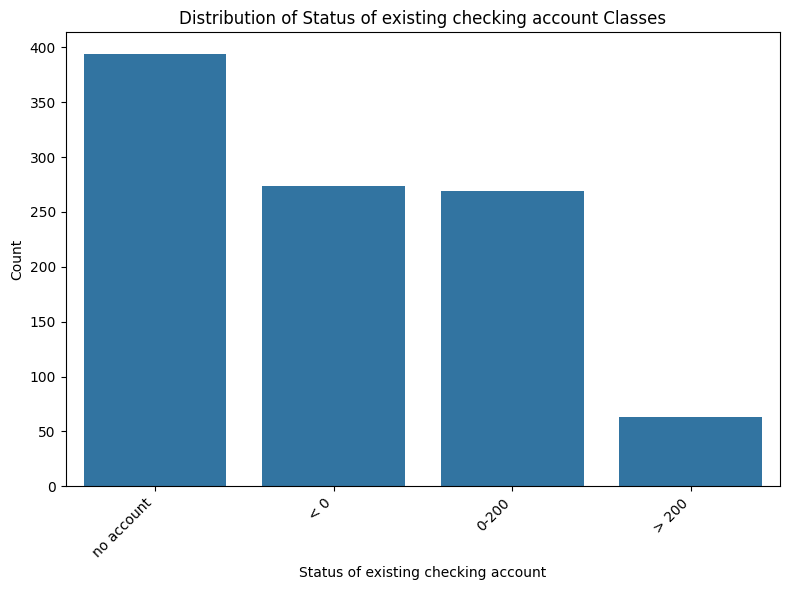

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='checking_status_string', data=X_features, order=X_features['checking_status_string'].value_counts().index)
plt.title('Distribution of Status of existing checking account Classes')
plt.xlabel('Status of existing checking account')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the checking_status_string featur against the targets

# Combine the feature and target into a single DataFrame for Plotly
# Assuming y_encoded is the one-hot encoded target (0 or 1)
# Let's use the original y for plotting as it's simpler for direct counting
df_plot = X_features.copy()
df_plot['Creditability'] = y

# Create a count plot using Plotly Express
fig = px.histogram(df_plot,
                   x='checking_status_string',
                   color='Creditability', # Use the target for coloring
                   barmode='group',     # Group bars by the target
                   title='Distribution of Checking Account Status by Creditability',
                   labels={'checking_status_string': 'Status of existing checking account',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig.update_layout(xaxis_title='Status of existing checking account',
                  yaxis_title='Count')

fig.show()

In [ ]:
X_features.columns

Index(['Status of existing checking account', 'Duration', 'Credit history',
       'Purpose', 'Credit amount', 'Savings account/bonds',
       'Present employment since',
       'Installment rate in percentage of disposable income',
       'Personal status and sex', 'Other debtors / guarantors',
       'Present residence since', 'Property', 'Age', 'Other installment plans',
       'Housing', 'Number of existing credits at this bank', 'Job',
       'Number of people being liable to provide maintenance for', 'Telephone',
       'Foreign worker', 'checking_status_encoded', 'checking_status_value',
       'checking_status_string'],
      dtype='object')

<Axes: ylabel='Duration'>

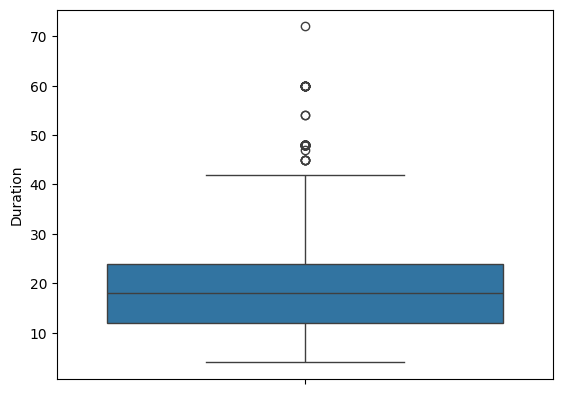

In [ ]:
# the Duration column

'''
Duration of the credit in months (loan term):
  To Do:
    - See the distribution of the values
    - May be combined with other features:
      - credit amount
      - employment
      - may be we need to remove the outlaiers

'''

sns.boxplot(y='Duration', data=X_features)



In [ ]:
# prompt: I want to use plotly to plot the Duration featur against the targets using representative visualization

# Visualize the relationship between 'Duration' and 'Creditability' using a box plot
df_plot = X_features.copy()
df_plot['Creditability'] = y

fig = px.box(df_plot,
             x='Creditability', # Use the target on the x-axis
             y='Duration',      # Use Duration on the y-axis
             title='Distribution of Duration by Creditability',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Duration': 'Duration (months)'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Duration (months)')

fig.show()

In [ ]:
# Credit history
'''
Credit history:
  A30: no credits taken/ all credits paid back duly
  A31: all credits at this bank paid back duly
  A32: existing credits paid back duly till now
  A33: delay in paying off in the past
  A34: critical account/ other credits existing (not at this bank)

To Do:
    -  we can do regular mapping to classes
    - we can merge the first two classes into one class with low risk as it's nearly the same
    -  the distrbution of the classes

'''

credit_history_map = {
    'A30': 0,  # best
    'A31': 1,
    'A32': 2,
    'A33': 3,
    'A34': 4   # worst
}

credit_history_merged_map = {
    'A30': 0,  # best
    'A31': 0,
    'A32': 2,
    'A33': 3,
    'A34': 4   # worst
}

credit_history_merged_map = {
    'A30': 0,  # best
    'A31': 0,
    'A32': 2,
    'A33': 3,
    'A34': 4   # worst
}

credit_history_stirng_map = {
    'A30': 'no credits taken/ all credits paid back duly',
    'A31': 'all credits at this bank paid back duly',
    'A32': 'existing credits paid back duly till now',
    'A33': 'delay in paying off in the past',
    'A34': 'critical account/ other credits existing'
}

X_features['credit_history_string'] = X_features['Credit history'].map(credit_history_stirng_map)

X_features['credit_history_encoded'] = X_features['Credit history'].map(credit_history_map)
X_features['credit_history_merged_encoded'] = X_features['Credit history'].map(credit_history_merged_map)



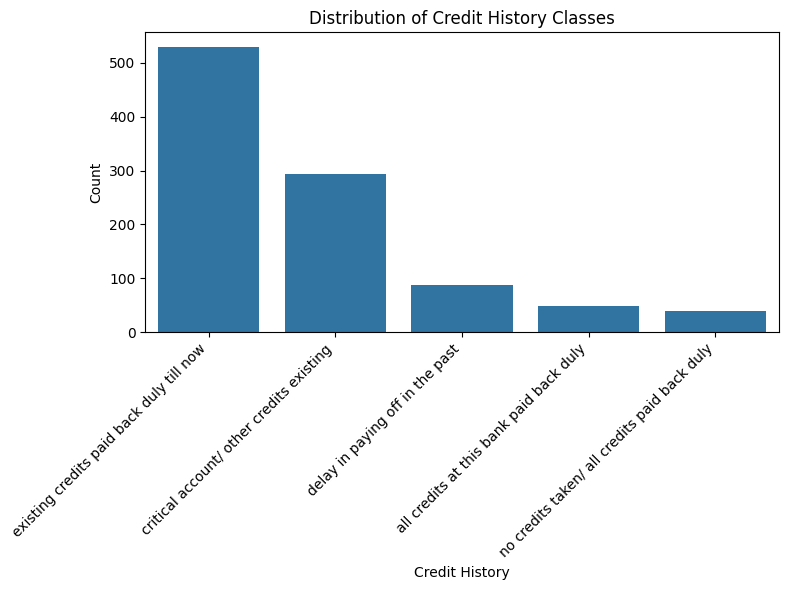

In [ ]:
# prompt: I want to plot the distribution of the classes in the credit history feature


plt.figure(figsize=(8, 6))
sns.countplot(x='credit_history_string', data=X_features, order=X_features['credit_history_string'].value_counts().index)
plt.title('Distribution of Credit History Classes')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the credit_history_string feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y

# Create a count plot using Plotly Express
fig = px.histogram(df_plot,
                   x='credit_history_string',
                   color='Creditability', # Use the target for coloring
                   barmode='group',     # Group bars by the target
                   title='Distribution of Credit History by Creditability',
                   labels={'credit_history_string': 'Credit History',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig.update_layout(xaxis_title='Credit History',
                  yaxis_title='Count')

fig.show()

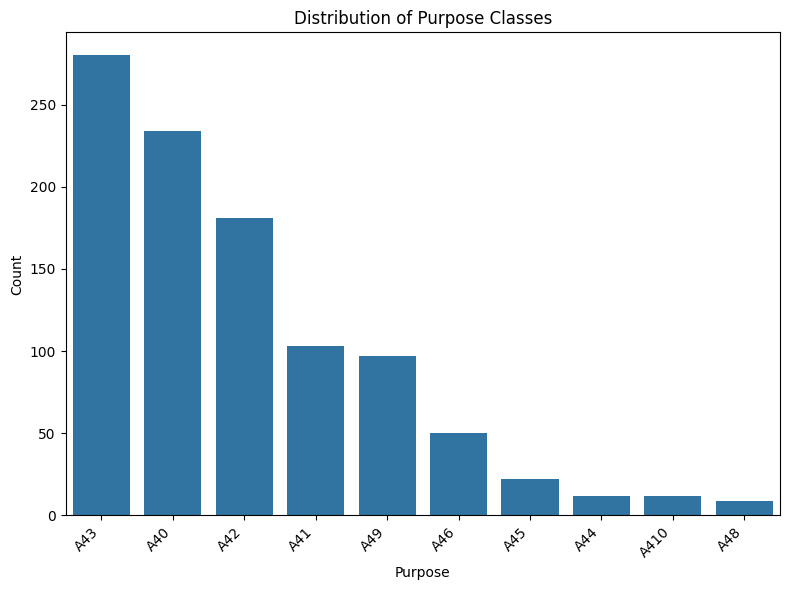

In [ ]:
# Purpose
'''
Purpose:
  A40: car (new)
  A41: car (used)
  A42: furniture/equipment
  A43: radio/television
  A44: domestic appliances
  A45: repairs
  A46: education
  A47: (vacation - does not exist?)
  A48: retraining
  A49: business
  A410: others


This feature tells what is the intention of the customer in doing this.
To do:
  -  we can combime classes that seems similar in the behaviour and the amount
  - we have two combinations  can be done: by the class or by the amount
'''

plt.figure(figsize=(8, 6))
sns.countplot(x='Purpose', data=X_features, order=X_features['Purpose'].value_counts().index)
plt.title('Distribution of Purpose Classes')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
## as we can see now most of the people use loans in Radio and TV `LOL`

## we can add different methods to group the puposes
def purpose_historical_group(code):
    if code in ['A42', 'A43', 'A44']:
        return 'essential_goods'
    elif code in ['A40', 'A41']:
        return 'transportation'
    elif code in ['A45', 'A46', 'A48']:
        return 'life_investment'
    elif code == 'A49':
        return 'business'
    else:
        return 'discretionary'


purpose_string_map = {
    'A40': 'new car',
    'A41': 'used car',
    'A42': 'furniture/equipment',
    'A43': 'radio/television',
    'A44': 'domestic appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'}

X_features['purpose_string'] = X_features['Purpose'].map(purpose_string_map)


X_features['purpose_historical_group'] = X_features['Purpose'].apply(purpose_historical_group)

In [ ]:
# prompt: I want to use plotly to plot the purpose_string feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y

# Create a count plot using Plotly Express
fig = px.histogram(df_plot,
                   x='purpose_string',
                   color='Creditability', # Use the target for coloring
                   barmode='group',     # Group bars by the target
                   title='Distribution of Purpose by Creditability',
                   labels={'purpose_string': 'Purpose',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig.update_layout(xaxis_title='Purpose',
                  yaxis_title='Count')

fig.show()

In [ ]:
X_features['Credit amount'].describe()


,Credit amount
count,1000.000000
mean,3271.258000
std,2822.736876
min,250.000000
25%,1365.500000
50%,2319.500000
75%,3972.250000
max,18424.000000


In [ ]:
X_features.groupby('purpose_string')['Credit amount'].agg(['mean', 'min', 'max']).sort_values(by='mean', ascending=False)


,mean,min,max
purpose_string,,,
others,8209.333333,1164,18424
used car,5370.223301,1236,12976
business,4158.041237,609,15945
education,3180.400000,392,12612
furniture/equipment,3066.988950,428,14179
new car,3063.025641,250,14896
repairs,2728.090909,454,11998
radio/television,2487.653571,338,15653
domestic appliances,1498.000000,343,3990


Text(0, 0.5, 'Frequency')

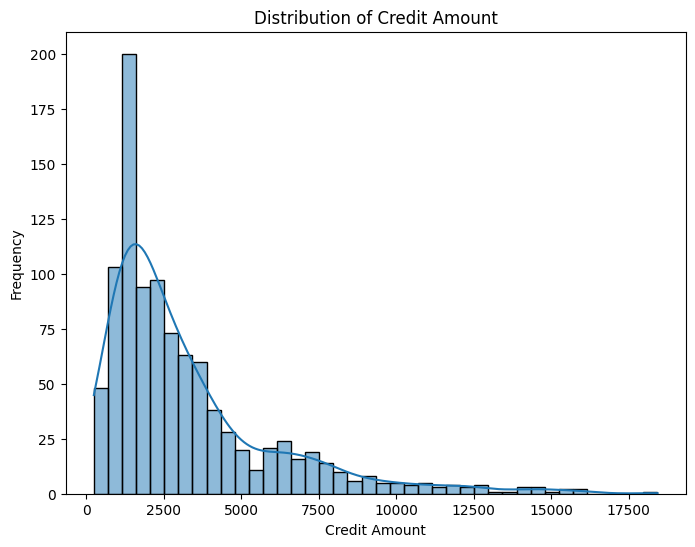

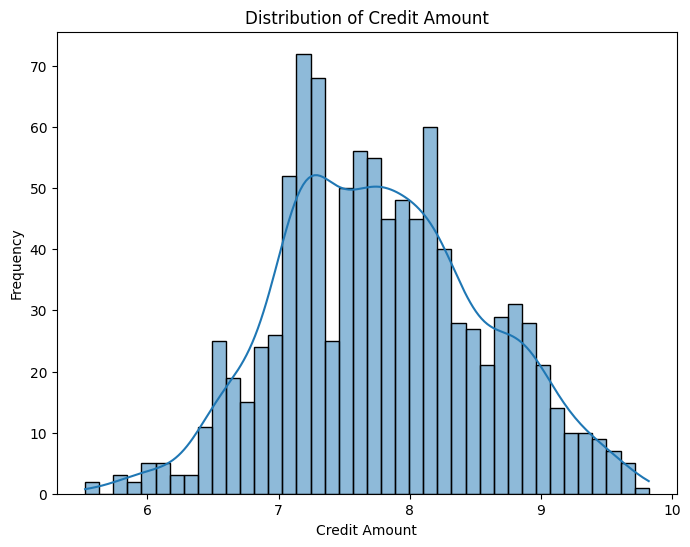

In [ ]:
#Credit amount
'''
Amount of credit requested by the applicant.

we can see the histogram of this feature to now if we need to bineraize this feature or not?
Wow it seems like to be left skewd so we want to make log of the values to make it nearer to the normal distribution
'''
X_features['credit_amount_log'] = np.log1p(X_features['Credit amount'])

plt.figure(figsize=(8, 6))
sns.histplot(X_features['Credit amount'], bins=40, kde=True)
plt.title('Distribution of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')

plt.figure(figsize=(8, 6))
sns.histplot(X_features['credit_amount_log'], bins=40, kde=True)
plt.title('Distribution of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')


In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a box plot to show distribution of credit amount per gender and creditability
fig = px.box(df_plot,
             x='gender', # Use gender on the x-axis
             y='Credit amount',
             color='Creditability', # Color by Creditability
             title='Distribution of Credit Amount by Gender and Creditability',
             labels={'gender': 'Gender',
                     'Credit amount': 'Credit Amount',
                     'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig.update_layout(xaxis_title='Gender',
                  yaxis_title='Credit Amount')

fig.show()

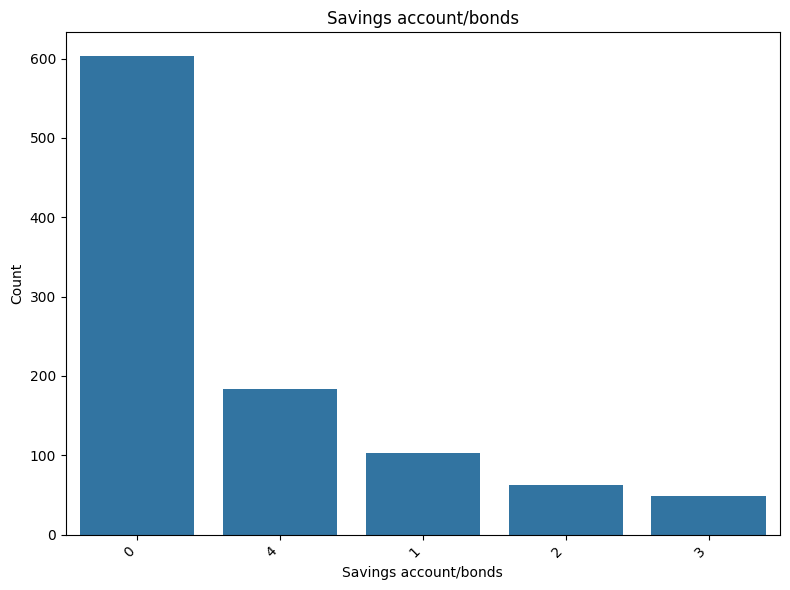

In [ ]:
# Savings account/bonds feature
'''
Savings account/bonds:
  A61: ... < 100 DM
  A62: 100 <= ... < 500 DM
  A63: 500 <= ... < 1000 DM
  A64: ... >= 1000 DM
  A65: unknown / no savings account

  Applicant's savings account balance

  To Do:
    - We can plot the classes distribution
    - map the classes to values
    - map the old classes to regular classes numbers
'''


savings_account_map = {
    'A61': 0,  # worst: very low savings
    'A62': 1,  # small savings
    'A63': 2,  # decent
    'A64': 3,  # best
    'A65': 4   # unknown = risky
}
X_features['savings_encoded'] = X_features['Savings account/bonds'].map(savings_account_map)


savings_value_map = {
    'A61': 50,
    'A62': 300,
    'A63': 750,
    'A64': 1000,
    'A65': 0  # unknown → safest to assume none
}

savings_string_map = {
    'A61': '< 100',
    'A62': '100-500',
    'A63': '500-1000',
    'A64': '>= 1000',
    'A65': 'unknown'
}

X_features['savings_string'] = X_features['Savings account/bonds'].map(savings_string_map)

X_features['savings_value_estimate'] = X_features['Savings account/bonds'].map(savings_value_map)

plt.figure(figsize=(8, 6))
sns.countplot(x='savings_encoded', data=X_features, order=X_features['savings_encoded'].value_counts().index)
plt.title('Savings account/bonds')
plt.xlabel('Savings account/bonds')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the savings_string feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y

# Create a count plot using Plotly Express
fig = px.histogram(df_plot,
                   x='savings_string',
                   color='Creditability', # Use the target for coloring
                   barmode='group',     # Group bars by the target
                   title='Distribution of Savings Account Status by Creditability',
                   labels={'savings_string': 'Savings account/bonds',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"savings_string": ['< 100', '100-500', '500-1000', '>= 1000', 'unknown']}) # Order categories

fig.update_layout(xaxis_title='Savings account/bonds',
                  yaxis_title='Count')

fig.show()

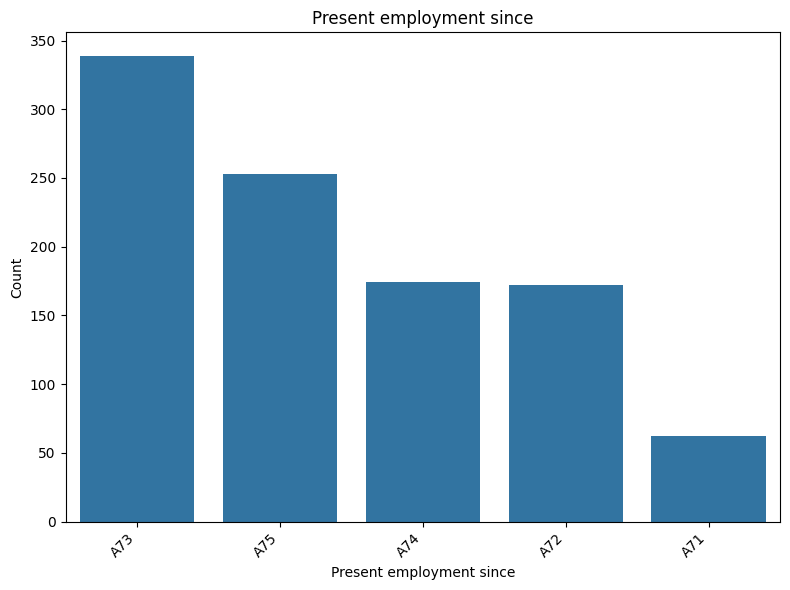

In [ ]:
# Present employment since

'''
This feature explains hte current employment status of the applicant.
 Duration of current employment.

Present employment since:
  A71: unemployed
  A72: ... < 1 year
  A73: 1 <= ... < 4 years
  A74: 4 <= ... < 7 years
  A75: ... >= 7 years

To Do:
  - We can plot the classes distribution
  - map the classes to values
  - map the old classes to regular classes numbers
  - Combine with Age <<
  - Create job stability index <<
'''

employment_map = {
    'A71': 0,  # Unemployed
    'A72': 1,  # < 1 year
    'A73': 2,  # 1–4 years
    'A74': 3,  # 4–7 years
    'A75': 4   # ≥ 7 years
}

X_features['employment_encoded'] = X_features['Present employment since'].map(employment_map)

employment_years_map = {
    'A71': 0,    # unemployed
    'A72': 0.5,  # <1 year
    'A73': 2.5,  # midpoint of 1–4
    'A74': 5.5,  # midpoint of 4–7
    'A75': 8     # assume minimum 7+
}

X_features['employment_years_estimate'] = X_features['Present employment since'].map(employment_years_map)

employment_string_map = {
    'A71': 'unemployed',
    'A72': '< 1 year',
    'A73': '1-4 years',
    'A74': '4-7 years',
    'A75': '>= 7 years'
}

X_features['employment_string'] = X_features['Present employment since'].map(employment_string_map)

plt.figure(figsize=(8, 6))
sns.countplot(x='Present employment since', data=X_features, order=X_features['Present employment since'].value_counts().index)
plt.title('Present employment since')
plt.xlabel('Present employment since')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the employment_string_map feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y

# Create a count plot using Plotly Express
fig = px.histogram(df_plot,
                   x='employment_string',
                   color='Creditability', # Use the target for coloring
                   barmode='group',     # Group bars by the target
                   title='Distribution of Present Employment Status by Creditability',
                   labels={'employment_string': 'Present employment since',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"employment_string": ['unemployed', '< 1 year', '1-4 years', '4-7 years', '>= 7 years']}) # Order categories

fig.update_layout(xaxis_title='Present employment since',
                  yaxis_title='Count')

fig.show()

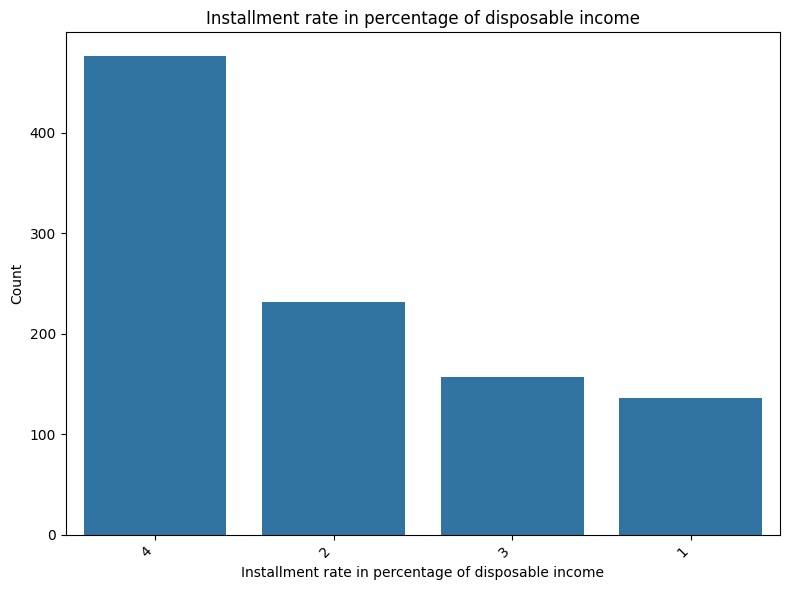

In [ ]:
#Installment rate in percentage of disposable income

'''
Portion of the applicant’s disposable income committed to paying installments
its an integer value for 1 to 4
he portion of the applicant’s income that will go toward repaying the loan each month, >> related to the financial stability of the customer
No need to change till now
'''

plt.figure(figsize=(8, 6))
sns.countplot(x='Installment rate in percentage of disposable income', data=X_features, order=X_features['Installment rate in percentage of disposable income'].value_counts().index)
plt.title('Installment rate in percentage of disposable income')
plt.xlabel('Installment rate in percentage of disposable income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the Installment rate in percentage of disposable income feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a violin plot using Plotly Express to show the distribution of installment rates for each creditability class
fig = px.violin(df_plot,
                x='Creditability',
                y='Installment rate in percentage of disposable income',
                box=True, # Show box plots inside the violins
                points="all", # Show all points
                title='Distribution of Installment Rate by Creditability',
                labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                        'Installment rate in percentage of disposable income': 'Installment Rate (%)'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Installment Rate (%)')

fig.show()

# Alternatively, a box plot can also be useful to compare quartiles
fig = px.box(df_plot,
             x='Creditability',
             y='Installment rate in percentage of disposable income',
             title='Distribution of Installment Rate by Creditability (Box Plot)',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Installment rate in percentage of disposable income': 'Installment Rate (%)'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Installment Rate (%)')

fig.show()

# A histogram can show the frequency distribution for each target class
fig = px.histogram(df_plot,
                   x='Installment rate in percentage of disposable income',
                   color='Creditability',
                   barmode='group', # or 'overlay'
                   nbins=4, # Since the values are 1 to 4
                   title='Distribution of Installment Rate by Creditability (Histogram)',
                   labels={'Installment rate in percentage of disposable income': 'Installment Rate (%)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig.update_layout(xaxis_title='Installment Rate (%)',
                  yaxis_title='Count')

fig.show()


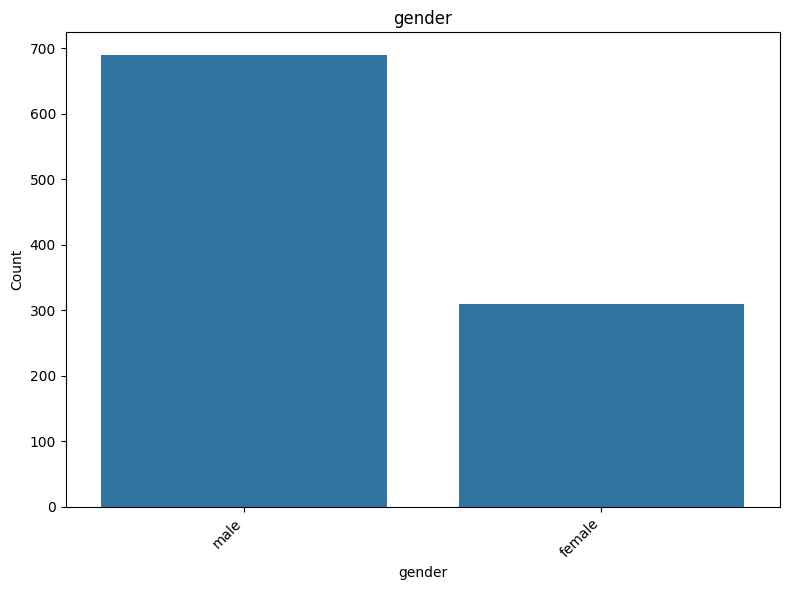

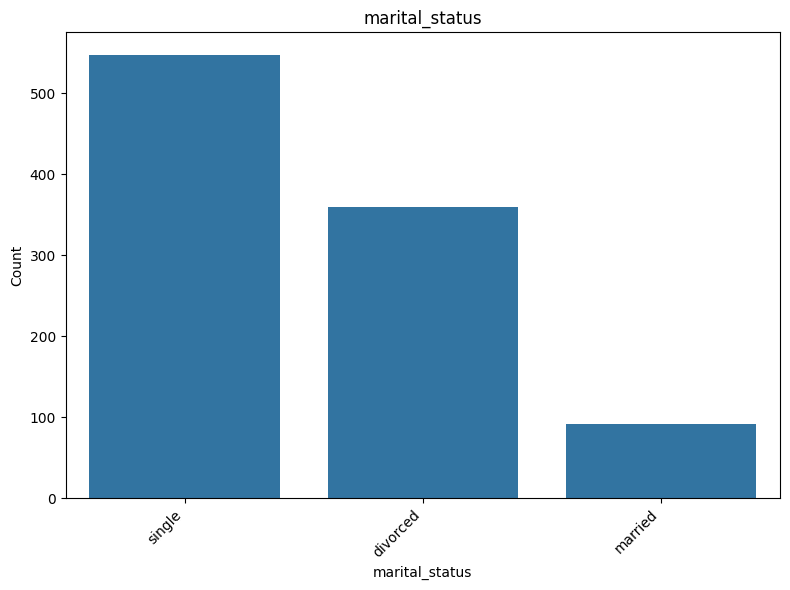

In [ ]:
#Personal status and sex

'''
combines gender and marital status into a single variable
marital status could imply different income sources for women

Personal status and sex:
  A91: male : divorced/separated
  A92: female : divorced/separated/married
  A93: male : married/widowed
  A94: male : single
  A95: female : single

Note that:
In real-world credit scoring, using gender directly may be illegal under anti-discrimination laws (like GDPR or Equal Credit Opportunity Act in the U.S.)

  To Do:
    - We can plot the classes distribution
    - map the old classes to regular classes numbers
    - split it into two features
    - study agian the classes why its combined like that
'''


def get_gender(code):
    if code in ['A91', 'A93', 'A94']:
        return 'male'
    else:
        return 'female'

def get_marital_status(code):
    if code in ['A91', 'A92']:
        return 'divorced'
    elif code in ['A93', 'A95']:
        return 'single'
    else:
        return 'married'

X_features['gender'] = X_features['Personal status and sex'].apply(get_gender)
X_features['marital_status'] = X_features['Personal status and sex'].apply(get_marital_status)

plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=X_features, order=X_features['gender'].value_counts().index)
plt.title('gender')
plt.xlabel('gender')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='marital_status', data=X_features, order=X_features['marital_status'].value_counts().index)
plt.title('marital_status')
plt.xlabel('marital_status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the gender,  marital_status feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot Gender vs. Creditability
fig_gender = px.histogram(df_plot,
                          x='gender',
                          color='Creditability',
                          barmode='group',
                          title='Distribution of Gender by Creditability',
                          labels={'gender': 'Gender',
                                  'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig_gender.update_layout(xaxis_title='Gender',
                         yaxis_title='Count')

fig_gender.show()

# Plot Marital Status vs. Creditability
fig_marital = px.histogram(df_plot,
                           x='marital_status',
                           color='Creditability',
                           barmode='group',
                           title='Distribution of Marital Status by Creditability',
                           labels={'marital_status': 'Marital Status',
                                   'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig_marital.update_layout(xaxis_title='Marital Status',
                          yaxis_title='Count')

fig_marital.show()

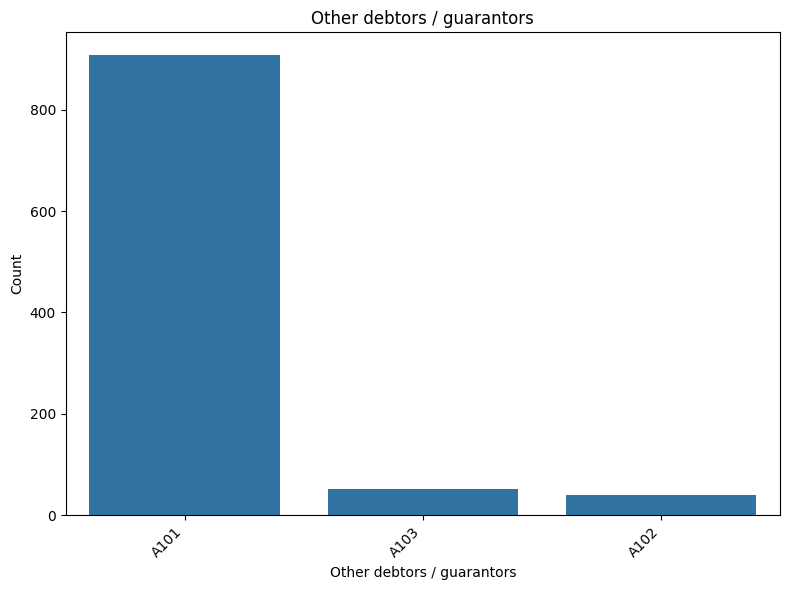

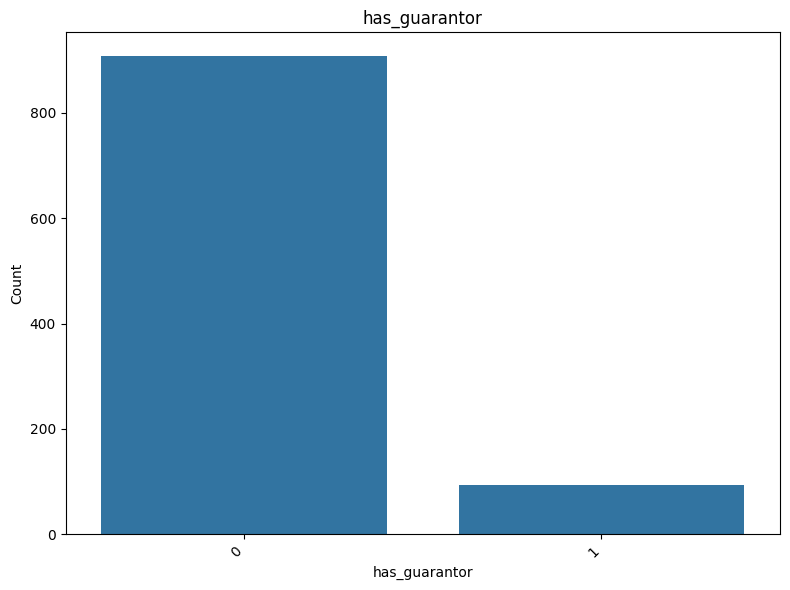

In [ ]:
#Other debtors / guarantors
'''
Whether the applicant has someone backing them financially

Other debtors / guarantors:
  A101: none
  A102: co-applicant
  A103: guarantor

  To Do:
    - We can plot the classes distribution
    - map the old classes to regular classes numbers
    - we can reduce it to binary feature yes or no


'''

other_guarantors_string_map = {
    'A101': 'none',
    'A102': 'co-applicant',
    'A103': 'guarantor'
}

X_features['other_guarantors_string'] = X_features['Other debtors / guarantors'].map(other_guarantors_string_map)

X_features['has_guarantor'] = X_features['Other debtors / guarantors'].apply(lambda x: 0 if x == 'A101' else 1)


plt.figure(figsize=(8, 6))
sns.countplot(x='Other debtors / guarantors', data=X_features, order=X_features['Other debtors / guarantors'].value_counts().index)
plt.title('Other debtors / guarantors')
plt.xlabel('Other debtors / guarantors')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.figure(figsize=(8, 6))
sns.countplot(x='has_guarantor', data=X_features, order=X_features['has_guarantor'].value_counts().index)
plt.title('has_guarantor')
plt.xlabel('has_guarantor')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the other_guarantors_string feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'Other debtors / guarantors' by 'Creditability'
fig = px.histogram(df_plot,
                   x='other_guarantors_string',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Other Debtors / Guarantors by Creditability',
                   labels={'other_guarantors_string': 'Other Debtors / Guarantors',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"other_guarantors_string": ['none', 'co-applicant', 'guarantor']})

fig.update_layout(xaxis_title='Other Debtors / Guarantors',
                  yaxis_title='Count')

fig.show()

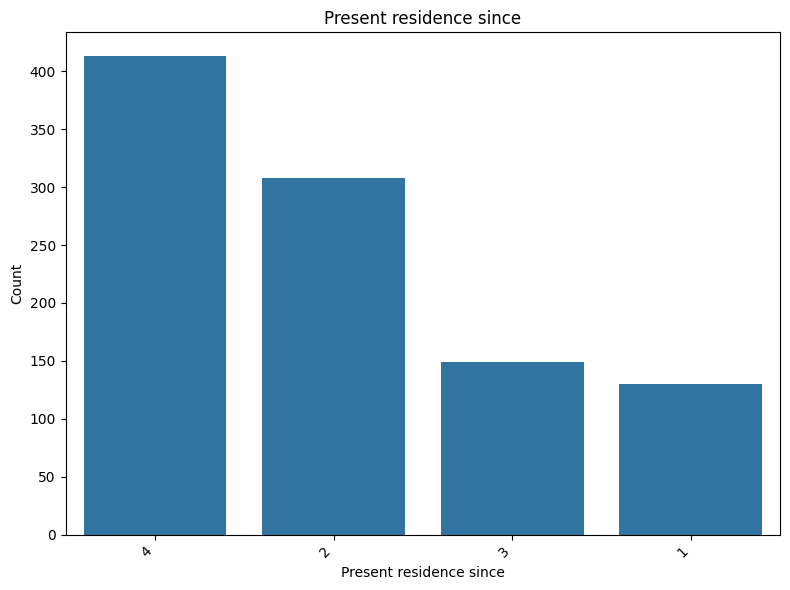

In [ ]:
#Present residence since

'''
Number of years the applicant has lived at their current address
 Lack of the information related to frequency of changing the adress

it's an integer feature so we can plot a histogram for it

To Do:
  - Plot a histogram of values
  - Combine it with the employment status
  - Combine it with the age
'''


plt.figure(figsize=(8, 6))
sns.countplot(x='Present residence since', data=X_features, order=X_features['Present residence since'].value_counts().index)
plt.title('Present residence since')
plt.xlabel('Present residence since')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# prompt: I want to use plotly to plot the Present residence since feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a count plot (histogram) using Plotly Express for 'Present residence since' vs. 'Creditability'
fig = px.histogram(df_plot,
                   x='Present residence since',
                   color='Creditability',
                   barmode='group', # or 'overlay'
                   nbins=4, # Since the values are 1 to 4 years
                   title='Distribution of Present Residence Since by Creditability',
                   labels={'Present residence since': 'Present residence since (years)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"Present residence since": [1, 2, 3, 4]}) # Explicitly order categories if they are numeric treated as discrete

fig.update_layout(xaxis_title='Present residence since (years)',
                  yaxis_title='Count')

fig.show()

# Alternatively, a box plot can show the distribution of years for each creditability class
fig = px.box(df_plot,
             x='Creditability',
             y='Present residence since',
             title='Distribution of Present Residence Since by Creditability (Box Plot)',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Present residence since': 'Present residence since (years)'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Present residence since (years)')

fig.show()

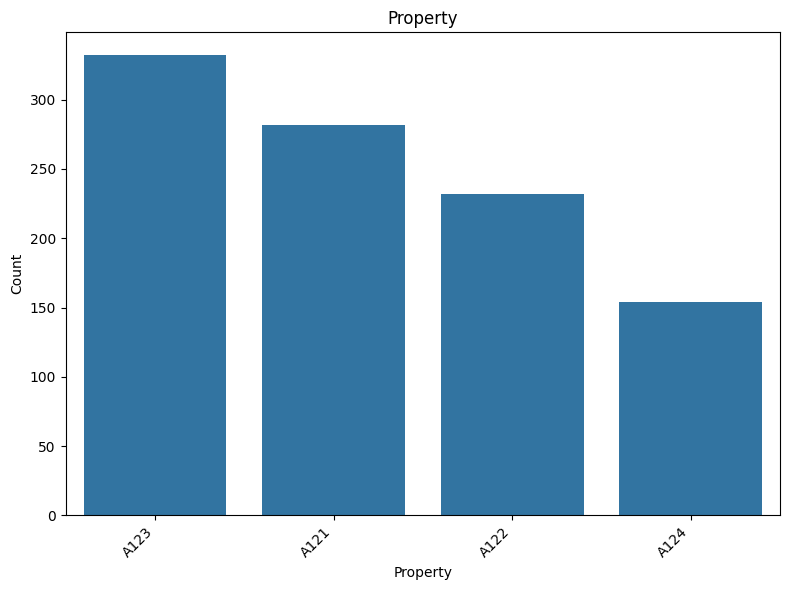

In [ ]:
# Property
'''
Type of property owned by the applicant (What if he has more than one of them?!)

  A121: real estate
  A122: building society savings agreement/life insurance
  A123: car or other, not in attribute 121 or 122
  A124: unknown / no property

  To Do:
    - We can plot the classes distribution
    - map the old classes to regular classes numbers
    - can be merged with the amount of credit or savings
'''


property_map = {
    'A124': 0,  # no assets
    'A123': 1,  # car/other
    'A122': 2,  # insurance/savings
    'A121': 3   # real estate
}

property_string_map = {
    'A124': 'unknown',
    'A123': 'car/other',
    'A122': 'insurance/savings',
    'A121': 'real estate'
}

X_features['property_string'] = X_features['Property'].map(property_string_map)
X_features['property_score'] = X_features['Property'].map(property_map)

plt.figure(figsize=(8, 6))
sns.countplot(x='Property', data=X_features, order=X_features['Property'].value_counts().index)
plt.title('Property')
plt.xlabel('Property')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the property_string feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'property_string' by 'Creditability'
fig = px.histogram(df_plot,
                   x='property_string',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Property Type by Creditability',
                   labels={'property_string': 'Property Type',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"property_string": ['unknown', 'car/other', 'insurance/savings', 'real estate']}) # Order categories

fig.update_layout(xaxis_title='Property Type',
                  yaxis_title='Count')

fig.show()

Text(0, 0.5, 'Frequency')

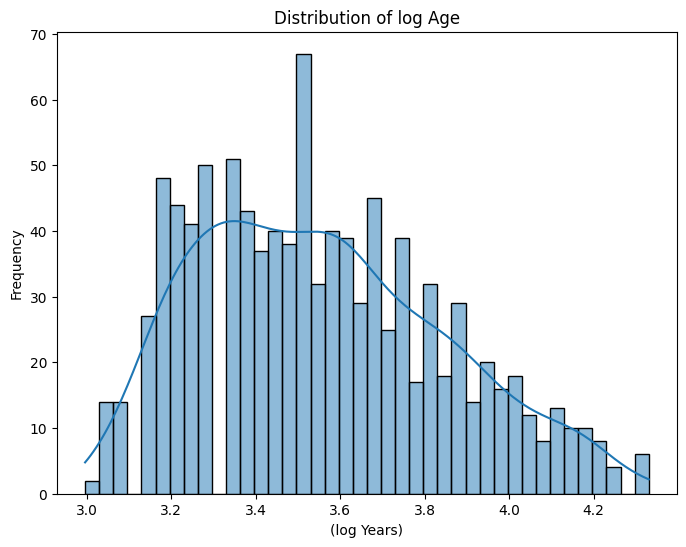

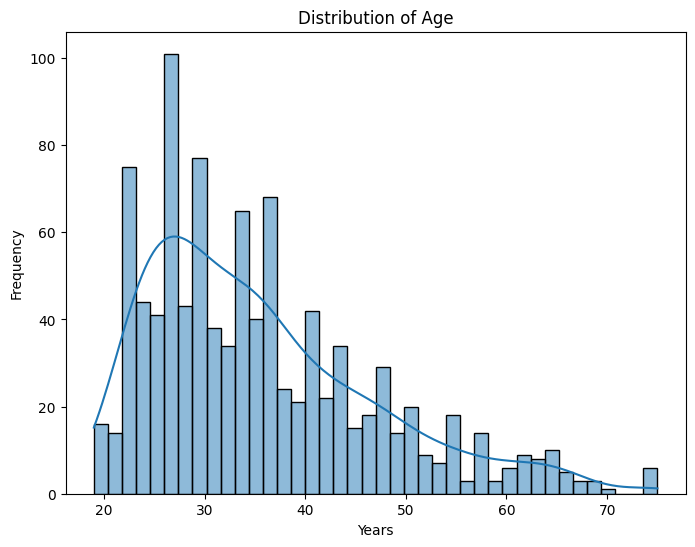

In [ ]:
# Age

'''
Age of the applicant in years

To Do:
  - Plot a histogram of values
  - Combine it with the employment status
  - Make log of it
  - binarize it into groups

  It's of course left skewed


'''

X_features['age_log'] = np.log1p(X_features['Age'])

plt.figure(figsize=(8, 6))
sns.histplot(X_features['age_log'], bins=40, kde=True)
plt.title('Distribution of log Age')
plt.xlabel('(log Years)')
plt.ylabel('Frequency')

plt.figure(figsize=(8, 6))
sns.histplot(X_features['Age'], bins=40, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Years')
plt.ylabel('Frequency')


In [ ]:
# prompt: I want to use plotly to plot the age feature against the targets using representative visualization

# Combine X_features and y for plotting
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a violin plot using Plotly Express to show the distribution of Age for each creditability class
fig = px.violin(df_plot,
                x='Creditability',
                y='Age',
                box=True, # Show box plots inside the violins
                points="all", # Show all points
                title='Distribution of Age by Creditability',
                labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                        'Age': 'Age (years)'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Age (years)')

fig.show()

# Alternatively, a box plot can also be useful to compare quartiles
fig = px.box(df_plot,
             x='Creditability',
             y='Age',
             title='Distribution of Age by Creditability (Box Plot)',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Age': 'Age (years)'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Age (years)')

fig.show()

# A histogram can show the frequency distribution for each target class
fig = px.histogram(df_plot,
                   x='Age',
                   color='Creditability',
                   barmode='group', # or 'overlay'
                   nbins=30, # Adjust number of bins as needed
                   title='Distribution of Age by Creditability (Histogram)',
                   labels={'Age': 'Age (years)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'})

fig.update_layout(xaxis_title='Age (years)',
                  yaxis_title='Count')

fig.show()

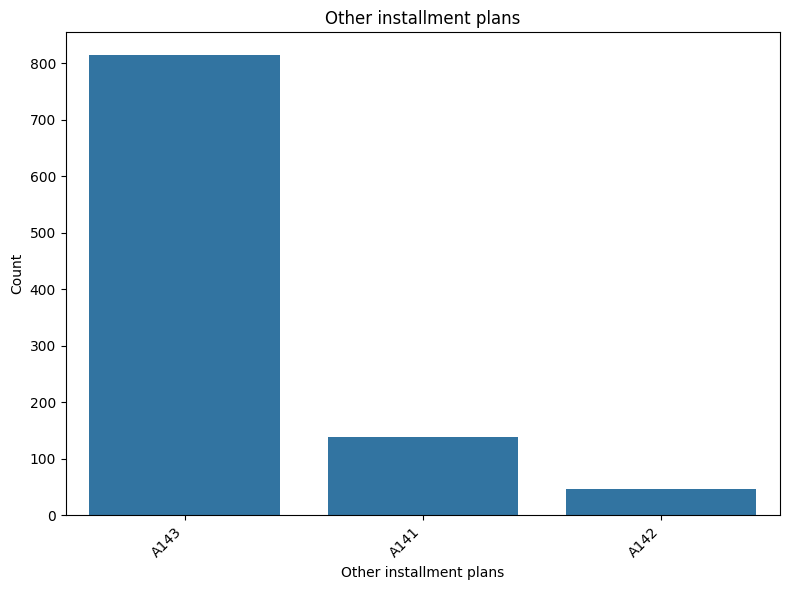

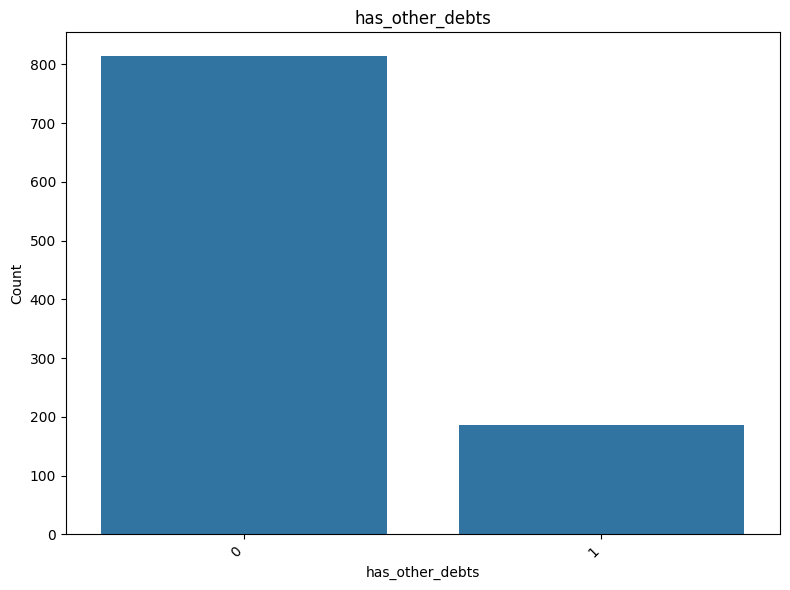

In [ ]:
#Other installment plans

'''
applicant is paying other installment debts (besides the current credit request) and to whom
  A141: bank
  A142: stores
  A143: none

  To Do:
    - We can plot the classes distribution
    - map the old classes to regular classes numbers
    - We can turn it into binary feature

'''

other_installment_string_map = {
    'A143': 'none',
    'A142': 'stores',
    'A141': 'bank'
}
X_features['other_installment_string'] = X_features['Other installment plans'].map(other_installment_string_map)

other_installment_map = {
    'A143': 0,  # no other debts
    'A142': 1,  # store-based (consumer)
    'A141': 2   # bank-based (formal/larger debts)
}
X_features['installment_obligation_score'] = X_features['Other installment plans'].map(other_installment_map)


X_features['has_other_debts'] = X_features['Other installment plans'].apply(lambda x: 0 if x == 'A143' else 1) # take care from the mapping

plt.figure(figsize=(8, 6))
sns.countplot(x='Other installment plans', data=X_features, order=X_features['Other installment plans'].value_counts().index)
plt.title('Other installment plans')
plt.xlabel('Other installment plans')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()



plt.figure(figsize=(8, 6))
sns.countplot(x='has_other_debts', data=X_features, order=X_features['has_other_debts'].value_counts().index)
plt.title('has_other_debts')
plt.xlabel('has_other_debts')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the other_installment_string feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'other_installment_string' by 'Creditability'
fig = px.histogram(df_plot,
                   x='other_installment_string',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Other Installment Plans by Creditability',
                   labels={'other_installment_string': 'Other Installment Plans',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"other_installment_string": ['none', 'stores', 'bank']}) # Order categories

fig.update_layout(xaxis_title='Other Installment Plans',
                  yaxis_title='Count')

fig.show()

# Also plot the binary version 'has_other_debts' for clarity
fig_binary = px.histogram(df_plot,
                          x='has_other_debts',
                          color='Creditability',
                          barmode='group',
                          title='Distribution of Has Other Debts by Creditability',
                          labels={'has_other_debts': 'Has Other Debts (0: No, 1: Yes)',
                                  'Creditability': 'Creditability (1: Good, 2: Bad)'},
                          category_orders={"has_other_debts": [0, 1]}) # Order categories

fig_binary.update_layout(xaxis_title='Has Other Debts (0: No, 1: Yes)',
                         yaxis_title='Count')

fig_binary.show()

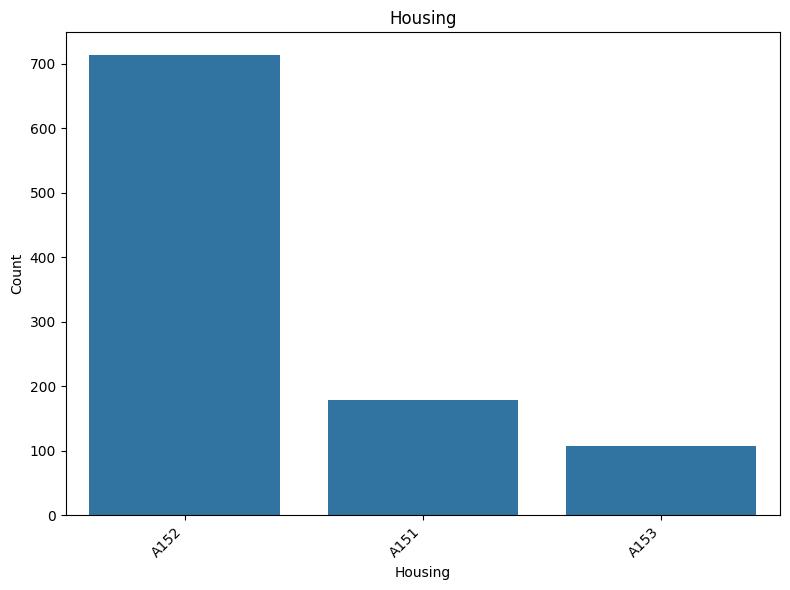

In [ ]:
# Housing

'''
Housing situation >> property also

  A151: rent
  A152: own
  A153: free

  To Do:
    - We can plot the classes distribution
    - map the old classes to regular classes numbers
    - We can turn it into binary feature
'''

housing_map_string = {
    'A153': 'free',
    'A152': 'own',
    'A151': 'rent'
}
X_features['housing_string'] = X_features['Housing'].map(housing_map_string)
housing_map = {
    'A153': 0,  # for free → lowest housing cost
    'A152': 1,  # own → may have taxes/mortgage
    'A151': 2   # rent → regular outgoing payments
}

X_features['housing_risk'] = X_features['Housing'].map(housing_map)



plt.figure(figsize=(8, 6))
sns.countplot(x='Housing', data=X_features, order=X_features['Housing'].value_counts().index)
plt.title('Housing')
plt.xlabel('Housing')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# prompt: I want to use plotly to plot the Housing feature against the targets using representative visualization

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'housing_string' by 'Creditability'
fig = px.histogram(df_plot,
                   x='housing_string',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Housing Status by Creditability',
                   labels={'housing_string': 'Housing Status',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"housing_string": ['rent', 'own', 'free']}) # Order categories based on count or assumed risk

fig.update_layout(xaxis_title='Housing Status',
                  yaxis_title='Count')

fig.show()

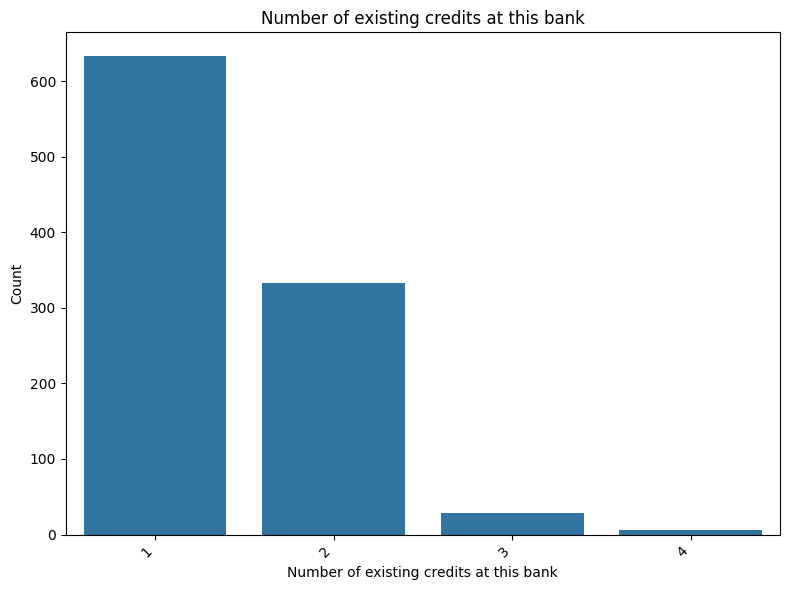

In [ ]:
# Number of existing credits at this bank
'''
Number of current credits the person already has with this bank
Here we can make a histogram of the values


'''
plt.figure(figsize=(8, 6))
sns.countplot(x='Number of existing credits at this bank', data=X_features, order=X_features['Number of existing credits at this bank'].value_counts().index)
plt.title('Number of existing credits at this bank')
plt.xlabel('Number of existing credits at this bank')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# prompt: I want to use plotly to plot the  Number of existing credits at this bank feature against the targets using representative visualization

# Combine X_features and y for plotting
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a histogram showing the distribution of the number of existing credits for each creditability class
fig = px.histogram(df_plot,
                   x='Number of existing credits at this bank',
                   color='Creditability',
                   barmode='group', # Use 'group' to compare counts side-by-side
                   title='Distribution of Number of Existing Credits by Creditability',
                   labels={'Number of existing credits at this bank': 'Number of Existing Credits',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   # Ensure all possible values (1, 2, 3, 4) are included in the x-axis
                   category_orders={"Number of existing credits at this bank": sorted(df_plot['Number of existing credits at this bank'].unique())})

fig.update_layout(xaxis_title='Number of Existing Credits at This Bank',
                  yaxis_title='Count')

fig.show()

# A box plot can show the distribution of credit counts per creditability class
fig = px.box(df_plot,
             x='Creditability',
             y='Number of existing credits at this bank',
             title='Distribution of Number of Existing Credits by Creditability (Box Plot)',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Number of existing credits at this bank': 'Number of Existing Credits'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Number of Existing Credits')

fig.show()

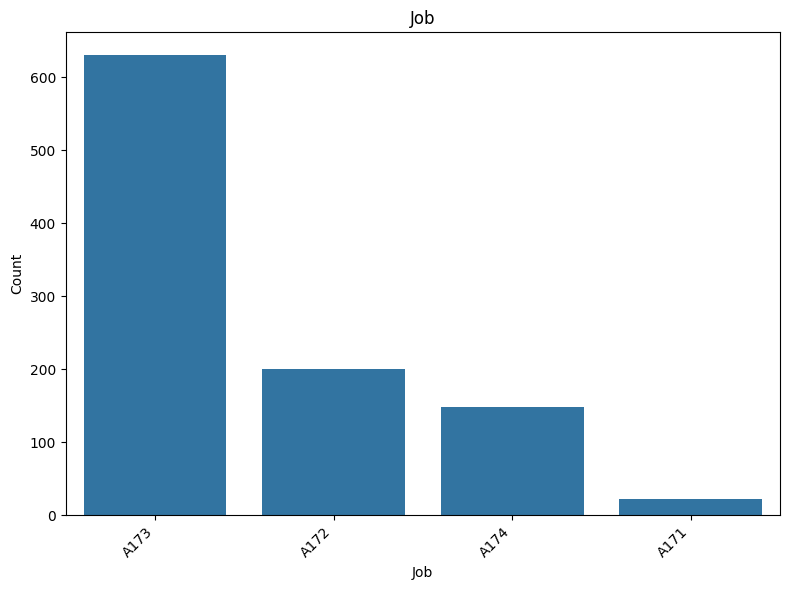

In [ ]:
# Job

'''
Job:
  A171: unemployed/unskilled - non-resident
  A172: unskilled - resident
  A173: skilled employee/official
  A174: management/self-employed/highly qualified employee/officer

  applicant's occupation level

To Do:
  - We can plot the classes distribution
  - map the old classes to regular classes numbers
  - We can turn it into binary feature
  - can be combined with other features (duration of the last employment)


'''

job_map = {
    'A171': 0,  # lowest level
    'A172': 1,
    'A173': 2,
    'A174': 3   # highest level
}

job_map_string = {
    'A171': 'unemployed/unskilled - non-resident',
    'A172': 'unskilled - resident',
    'A173': 'skilled employee/official',
    'A174': 'management/highly qualified employee'
}

X_features['job_string'] = X_features['Job'].map(job_map_string)

X_features['job_level'] = X_features['Job'].map(job_map)

X_features['is_unemployed'] = (X_features['Job'] == 'A171').astype(int)

plt.figure(figsize=(8, 6))
sns.countplot(x='Job', data=X_features, order=X_features['Job'].value_counts().index)
plt.title('Job')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'job_string' by 'Creditability'
fig = px.histogram(df_plot,
                   x='job_string',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Job Type by Creditability',
                   labels={'job_string': 'Job Type',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"job_string": ['unemployed/unskilled - non-resident', 'unskilled - resident', 'skilled employee/official', 'management/highly qualified employee']}) # Order categories

fig.update_layout(xaxis_title='Job Type',
                  yaxis_title='Count')

fig.show()

# Plot the distribution of 'is_unemployed' by 'Creditability'
fig_unemployed = px.histogram(df_plot,
                              x='is_unemployed',
                              color='Creditability',
                              barmode='group',
                              title='Distribution of Unemployed Status by Creditability',
                              labels={'is_unemployed': 'Unemployed (0: No, 1: Yes)',
                                      'Creditability': 'Creditability (1: Good, 2: Bad)'},
                              category_orders={"is_unemployed": [0, 1]}) # Order categories

fig_unemployed.update_layout(xaxis_title='Unemployed (0: No, 1: Yes)',
                             yaxis_title='Count')

fig_unemployed.show()

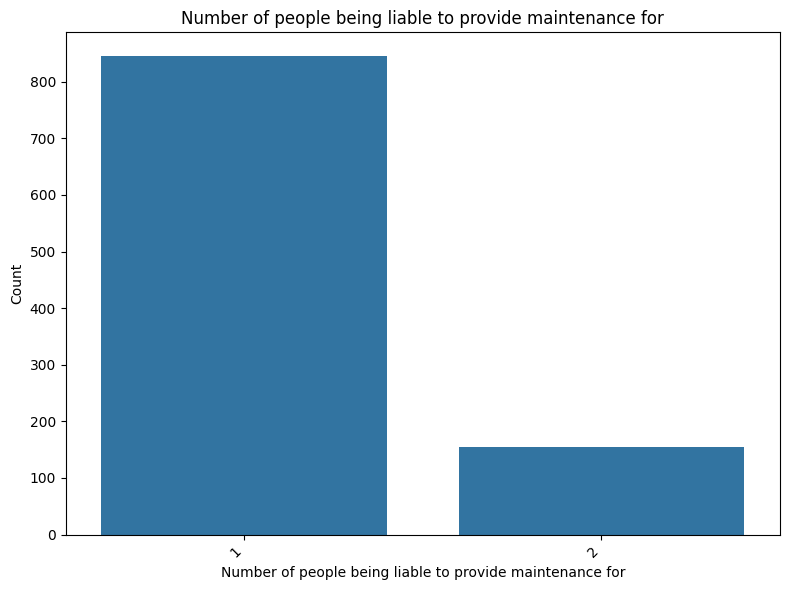

In [ ]:
#Number of people being liable to provide maintenance for

'''
 Number of dependents (e.g., children, elderly) the applicant financially supports

  To Do:
    - We can plot the classes distribution
    - No change
'''


plt.figure(figsize=(8, 6))
sns.countplot(x='Number of people being liable to provide maintenance for', data=X_features, order=X_features['Number of people being liable to provide maintenance for'].value_counts().index)
plt.title('Number of people being liable to provide maintenance for')
plt.xlabel('Number of people being liable to provide maintenance for')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array


# Plot the distribution of 'Number of people being liable to provide maintenance for' by 'Creditability'
fig = px.histogram(df_plot,
                   x='Number of people being liable to provide maintenance for',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Number of Dependents by Creditability',
                   labels={'Number of people being liable to provide maintenance for': 'Number of Dependents',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"Number of people being liable to provide maintenance for": sorted(df_plot['Number of people being liable to provide maintenance for'].unique())}) # Order categories

fig.update_layout(xaxis_title='Number of Dependents',
                  yaxis_title='Count')

fig.show()

# A box plot can also show the distribution of dependent counts per creditability class
fig = px.box(df_plot,
             x='Creditability',
             y='Number of people being liable to provide maintenance for',
             title='Distribution of Number of Dependents by Creditability (Box Plot)',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Number of people being liable to provide maintenance for': 'Number of Dependents'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Number of Dependents')

fig.show()

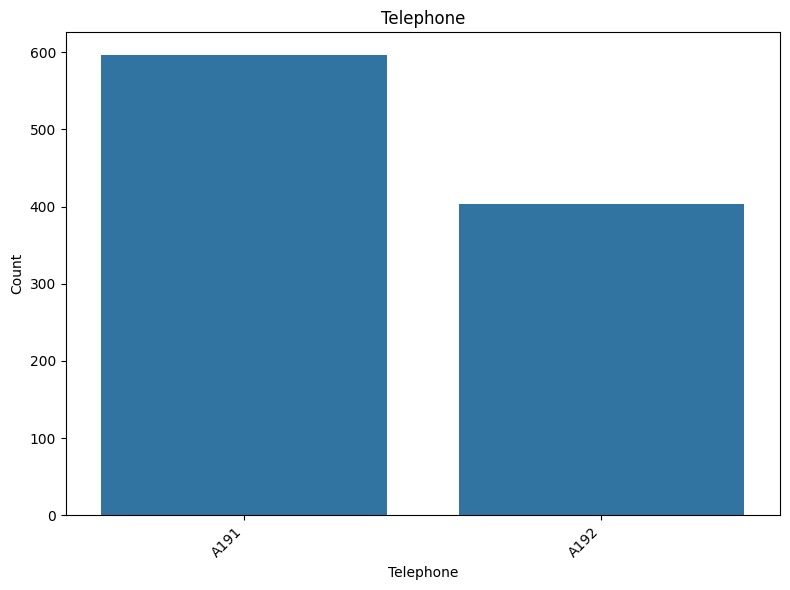

In [ ]:
#Telephone
'''
Whether the applicant has a telephone.

  To Do:
    - We can plot the classes distribution
    - map the old classes to binary classes
'''

telephone_map = {
    'A191': 0,  # no phone
    'A192': 1   # has phone
}
X_features['has_telephone'] = X_features['Telephone'].map(telephone_map)

plt.figure(figsize=(8, 6))
sns.countplot(x='Telephone', data=X_features, order=X_features['Telephone'].value_counts().index)
plt.title('Telephone')
plt.xlabel('Telephone')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [ ]:

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'has_telephone' by 'Creditability'
fig = px.histogram(df_plot,
                   x='has_telephone',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Telephone Ownership by Creditability',
                   labels={'has_telephone': 'Has Telephone (0: No, 1: Yes)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"has_telephone": [0, 1]}) # Order categories

fig.update_layout(xaxis_title='Has Telephone (0: No, 1: Yes)',
                  yaxis_title='Count')

fig.show()


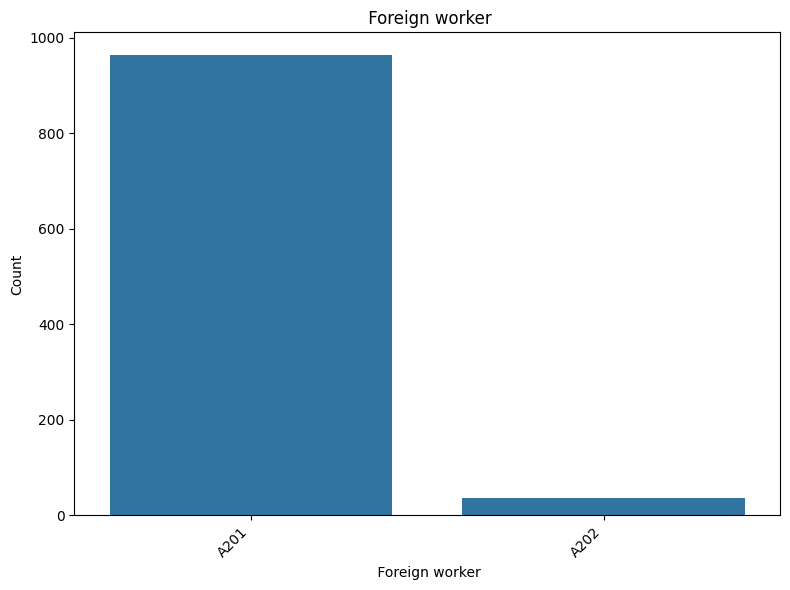

In [ ]:
# Foreign worker

foreign_worker_map = {
    'A201': 1,  # foreign
    'A202': 0   # native
}
X_features['is_foreign'] = X_features['Foreign worker'].map(foreign_worker_map)

plt.figure(figsize=(8, 6))
sns.countplot(x='Foreign worker', data=X_features, order=X_features['Foreign worker'].value_counts().index)
plt.title(' Foreign worker')
plt.xlabel(' Foreign worker')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'is_foreign' by 'Creditability'
fig = px.histogram(df_plot,
                   x='is_foreign',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Foreign Worker Status by Creditability',
                   labels={'is_foreign': 'Is Foreign Worker (0: No, 1: Yes)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"is_foreign": [0, 1]}) # Order categories

fig.update_layout(xaxis_title='Is Foreign Worker (0: No, 1: Yes)',
                  yaxis_title='Count')

fig.show()

In [ ]:
for col in X_features.columns:
    print(col)
    print(X_features[col].unique())
    print("-------------------------------------------")
# features wil be one hot encoded:
# features in old format and didn't transformed:
# features will be removed: Status of existing checking account, Credit history, Savings account/bonds, Present employment since, Personal status and sex, Other debtors / guarantors, Property, Other installment plans, Housing, Job, Telephone, Foreign worker
final_features = ['Duration',
                            'Purpose',
                  'Credit amount',
                  'Installment rate in percentage of disposable income',
                  'Present residence since',
                  'Age',
                  'Number of existing credits at this bank',
                  'Number of people being liable to provide maintenance for',
                  'checking_status_encoded',
                  'savings_encoded',
                  'employment_encoded',
                  'credit_history_encoded',
                  'purpose_historical_group',
                  'checking_status_value',
                  'credit_history_merged_encoded',
                  'savings_value_estimate',
                  'employment_years_estimate',
                  'credit_amount_log',
                  'installment_obligation_score',
                  'gender',
                  'marital_status',
                  'has_guarantor',
                  'property_score',
                  'age_log',
                  'has_other_debts',
                  'housing_risk',
                  'job_level',
                  'is_unemployed',
                  'has_telephone',
                  'is_foreign'
                  ]
X_final = X_features[final_features]

Status of existing checking account
['A11' 'A12' 'A14' 'A13']
-------------------------------------------
Duration
[ 6 48 12 42 24 36 30 15  9 10  7 60 18 45 11 27  8 54 20 14 33 21 16  4
 47 13 22 39 28  5 26 72 40]
-------------------------------------------
Credit history
['A34' 'A32' 'A33' 'A30' 'A31']
-------------------------------------------
Purpose
['A43' 'A46' 'A42' 'A40' 'A41' 'A49' 'A44' 'A45' 'A410' 'A48']
-------------------------------------------
Credit amount
[ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 1

In [ ]:
X_final['Present residence since']

,Present residence since
0,4
1,2
2,3
3,4
4,4
...,...
995,4
996,4
997,4
998,4


In [ ]:
for col in X_final.columns:
    print(col)
    print(X_features[col].unique())
    print("-------------------------------------------")

Duration
[ 6 48 12 42 24 36 30 15  9 10  7 60 18 45 11 27  8 54 20 14 33 21 16  4
 47 13 22 39 28  5 26 72 40]
-------------------------------------------
Purpose
['A43' 'A46' 'A42' 'A40' 'A41' 'A49' 'A44' 'A45' 'A410' 'A48']
-------------------------------------------
Credit amount
[ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  1264  1474  4746
  6110  2100  1225   458  2333  1158  6204  6187  6143  1393  2299  1352
  7228  2073  5965  1262  3378  2225   783  6468  9566  1961  6229  1391
  1537  1953 14421  3181  5190  2171  1007  1819  2394  8133   730  1164
  5954  1977  1526  3965  4771  9436  3832  5943  1213  1568  1755  2315
  1412 12612  2249  1108   618  1409   797  3617  1318 15945  2012  2622
  2337  7057  1469  2323   932  1919  2445 11938  6458  6078  7721  1410
  1449   392  6260  7855  1680  3578  7174  2132  4281  236

- Covarient Analysis with targets:
  - Purpose, Demographics with targets
  - Duration
  Percentages, counts
  Use plotly

- Focus on visalization of the feaures.
- Coorelation analysis


In [ ]:
#Covarient analysis
# Type A: Numeric × Numeric
numeric_numeric_pairs = [
    ('Credit amount', 'Duration'),
    ('Duration', 'Present residence since'),
    ('Duration', 'Age'),
    ('Duration', 'employment_years_estimate'),
]

# Type B: Categorical × Numeric
categorical_numeric_pairs = [
    ('Purpose', 'Duration'),
    ('marital_status', 'Duration'),
    ('gender', 'Duration'),
    ('Installment rate in percentage of disposable income', 'Duration') ,
    ('checking_status_encoded', 'Duration'),
    ('savings_encoded', 'Duration'),
    ('employment_encoded', 'Duration'),
    ('credit_history_encoded', 'Duration'),
]

# Type C: Categorical × Categorical
categorical_categorical_pairs = [
    ('Purpose', 'housing_risk'),
    ('job_level', 'credit_history_merged_encoded')
]

In [ ]:
# what I need to do:
'''
I need to visualize and group the persons based on the dempgraphics with the targets
  So, we can focus for now on the distribution of each class values vs the targest
  naming the values
'''

<Figure size 600x400 with 0 Axes>

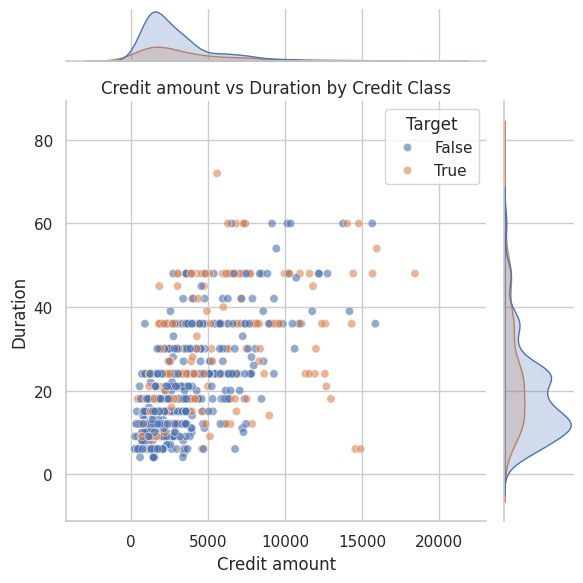

<Figure size 600x400 with 0 Axes>

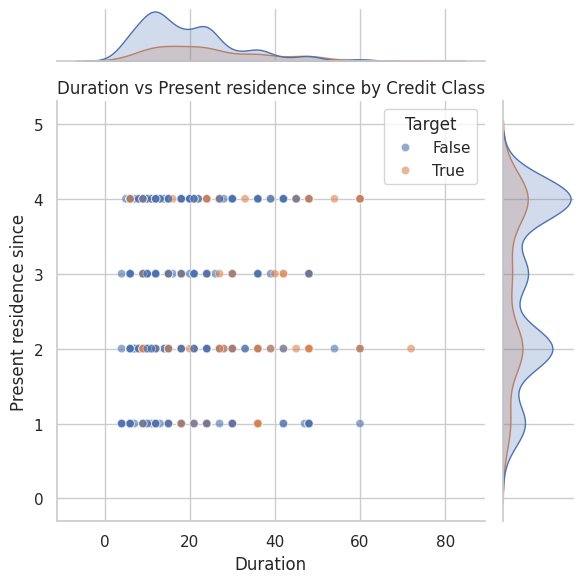

<Figure size 600x400 with 0 Axes>

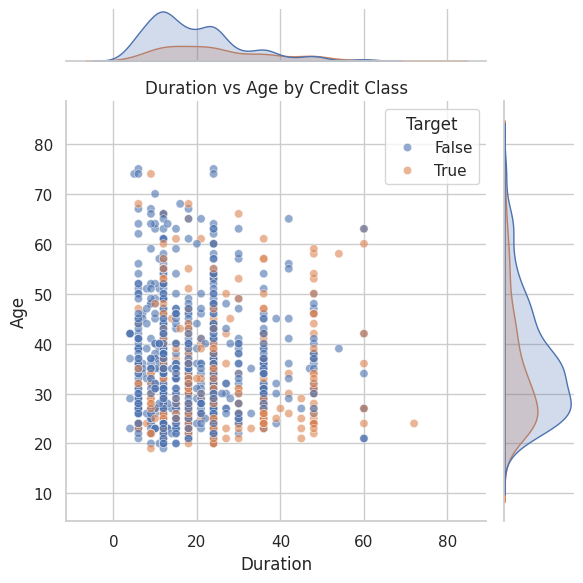

<Figure size 600x400 with 0 Axes>

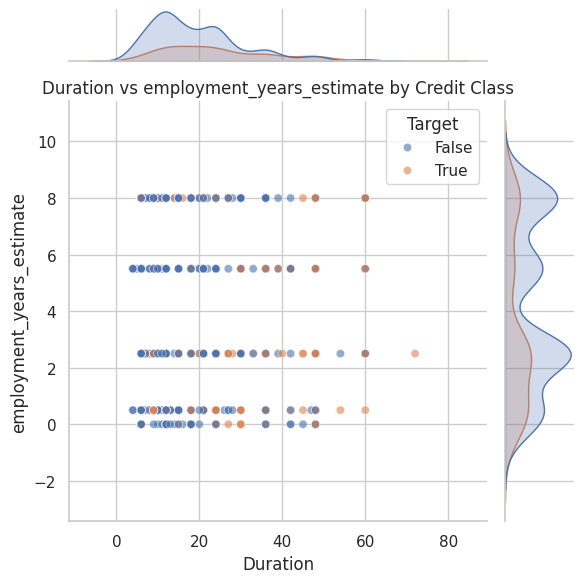

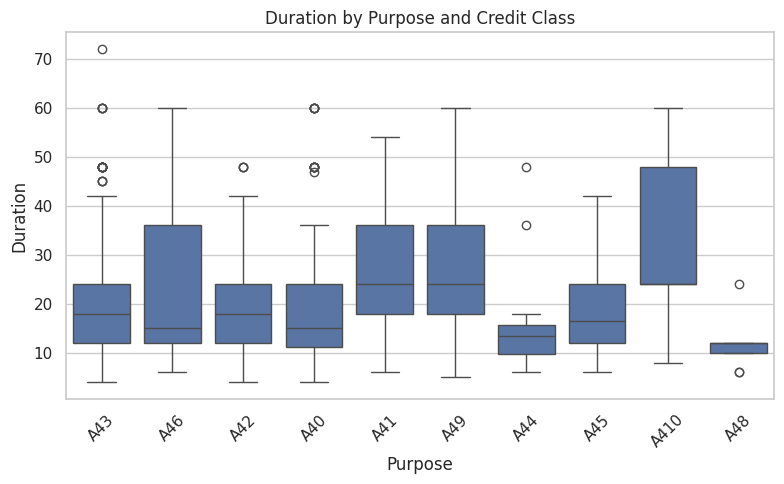

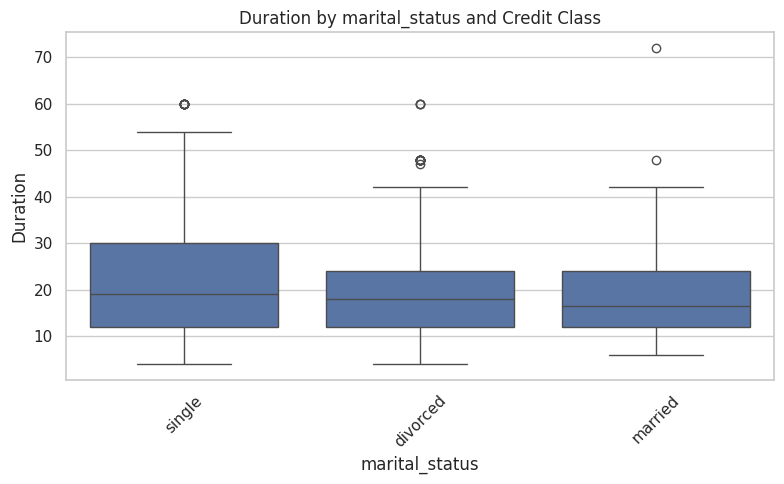

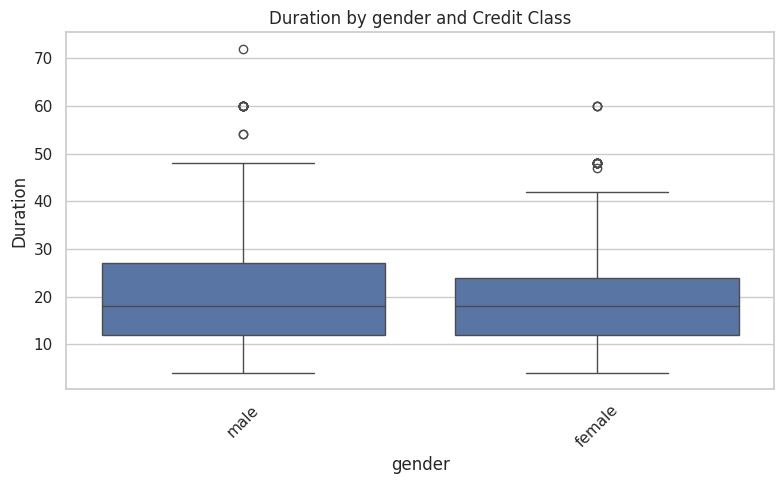

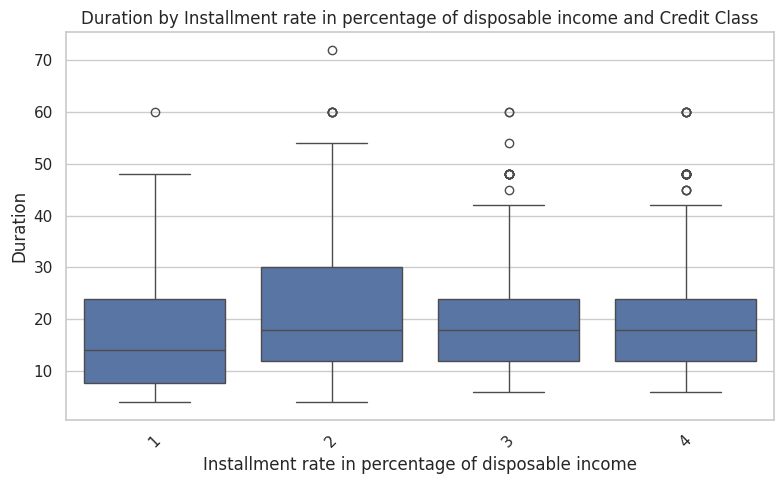

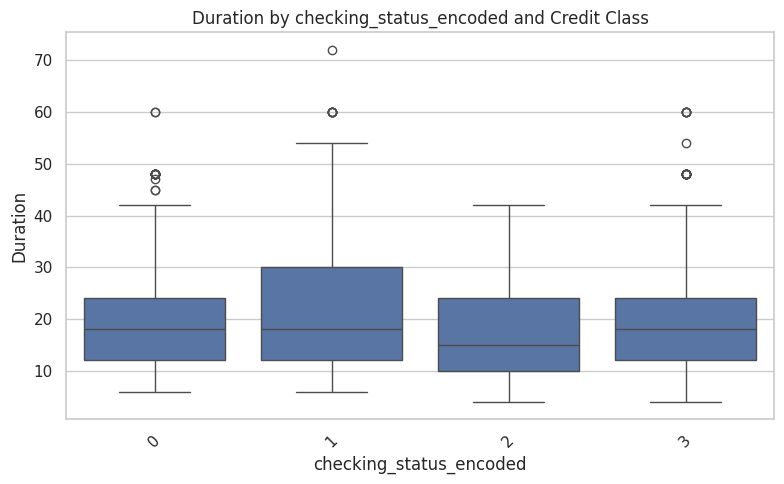

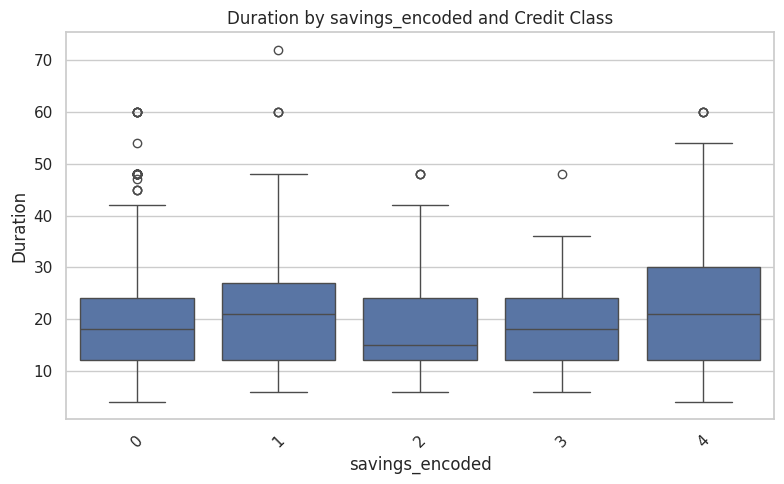

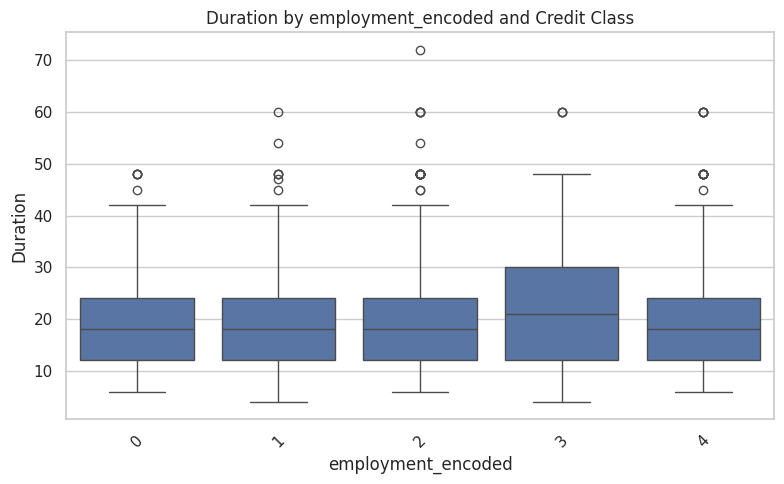

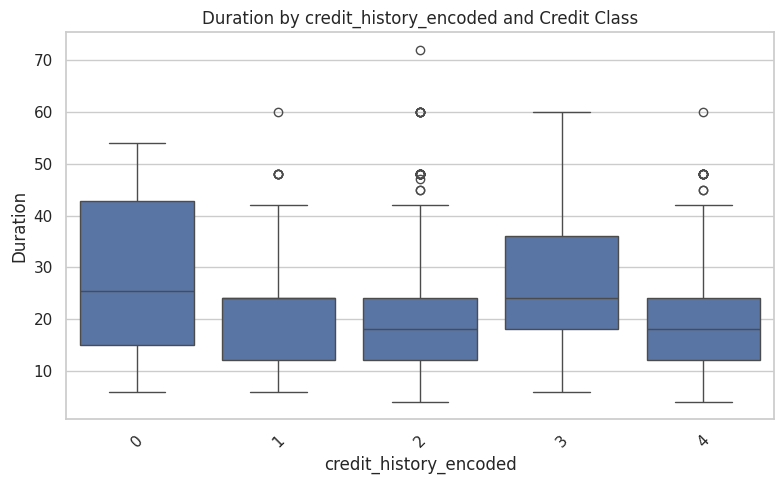

In [ ]:
target = y_encoded.values.ravel()

# Set Seaborn style
sns.set(style="whitegrid")

# Plot Numeric × Numeric
for x, y in numeric_numeric_pairs:
    plt.figure(figsize=(6, 4))
    sns.jointplot(data=X_features, x=x, y=y, hue=target, alpha=0.6)
    plt.title(f"{x} vs {y} by Credit Class")
    plt.legend(title="Target")
    plt.tight_layout()
    plt.show()

# Plot Categorical × Numeric
for cat, num in categorical_numeric_pairs:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=X_features, x=cat, y=num)
    plt.title(f"{num} by {cat} and Credit Class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# # Plot Categorical × Categorical
# for cat1, cat2 in categorical_categorical_pairs:
#     cross_tab = pd.crosstab(X_features[cat1], X_features[cat2],
#                             values=target, aggfunc='mean').fillna(0)
#     plt.figure(figsize=(8, 5))
#     sns.heatmap(cross_tab, annot=True, cmap="YlGnBu", fmt=".2f")
#     plt.title(f"Default Rate by {cat1} × {cat2}")
#     plt.tight_layout()
#     plt.show()

In [ ]:
one_hot_encoded_features = ['job_level','property_score', 'marital_status','gender','employment_encoded',  'savings_encoded', 'purpose_historical_group', 'credit_history_encoded','credit_history_merged_encoded','checking_status_encoded','Purpose']
features = [
            'Duration',
             'Purpose',
             'Credit amount',
             'Installment rate in percentage of disposable income',
             'Present residence since',
             'Age',
             'Number of existing credits at this bank',
             'Number of people being liable to provide maintenance for',
             'checking_status_encoded',
             'savings_encoded',
             'employment_encoded',
             'credit_history_encoded',
            #  'purpose_historical_group',
            #  'checking_status_value',
            #  'credit_history_merged_encoded',
             'savings_value_estimate',
             'employment_years_estimate',
            #  'credit_amount_log',
             'installment_obligation_score',
             'gender',
             'marital_status',
             'has_guarantor',
             'property_score',
            #  'age_log',
             'has_other_debts',
             'housing_risk',
             'job_level',
             'is_unemployed',
             'has_telephone',
             'is_foreign'
             ]


X_train = X_features[features]


# applying one hot encoding
X_cat = []
for col in X_train.columns:
    if col in one_hot_encoded_features:
        X_cat.append(col)
X_train_encoded = pd.get_dummies(X_train, columns=X_cat)


# 5-Fold Cross-Validation
rf_5fold = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_5fold = cross_val_score(rf_5fold, X_train_encoded, y_encoded.values.ravel(), cv=kf)

print("5-Fold Cross-Validation Scores:", cv_scores_5fold)
print("Average 5-Fold CV Score:", cv_scores_5fold.mean())



5-Fold Cross-Validation Scores: [0.785 0.765 0.7   0.785 0.765]
Average 5-Fold CV Score: 0.76


In [ ]:
# Univariat with tarfets,

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# I am intentinally didtn't handled the imbalance
#LOFO analysis
y_true = y_encoded.values.ravel()
results = []

for excluded_feature in features:
    print(f"\nExcluding Feature: {excluded_feature}")

    selected_features = [f for f in features if f != excluded_feature]
    X_selected = X_features[selected_features]
    X_cat = [col for col in selected_features if col in one_hot_encoded_features]
    X_encoded = pd.get_dummies(X_selected, columns=X_cat)

    # Setup model and cross-validation
    rf = RandomForestClassifier(random_state=42)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(rf, X_encoded, y_true, cv=kf)

    # Evaluate
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # Print summary
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Save result
    results.append({
        'excluded_feature': excluded_feature,
        'accuracy': acc,
        'f1_good': report['True']['f1-score'],
        'f1_bad': report['False']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
        'conf_matrix': cm
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)

print("\n📊 Summary (Sorted by Accuracy):")
print(results_df[['excluded_feature', 'accuracy', 'f1_good', 'f1_bad', 'macro_f1']])



Excluding Feature: Duration
Accuracy: 0.7580
Confusion Matrix:
[[645  55]
 [187 113]]
Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.92      0.84       700
        True       0.67      0.38      0.48       300

    accuracy                           0.76      1000
   macro avg       0.72      0.65      0.66      1000
weighted avg       0.74      0.76      0.73      1000


Excluding Feature: Purpose
Accuracy: 0.7610
Confusion Matrix:
[[646  54]
 [185 115]]
Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.92      0.84       700
        True       0.68      0.38      0.49       300

    accuracy                           0.76      1000
   macro avg       0.73      0.65      0.67      1000
weighted avg       0.75      0.76      0.74      1000


Excluding Feature: Credit amount
Accuracy: 0.7480
Confusion Matrix:
[[638  62]
 [190 110]]
Classification Report:
            

KeyboardInterrupt: 

In [ ]:
results_df

,excluded_feature,accuracy,f1_good,f1_bad,macro_f1,conf_matrix
20,housing_risk,0.778,0.533613,0.854331,0.693972,"[[651, 49], [173, 127]]"
19,has_other_debts,0.774,0.521186,0.852094,0.686640,"[[651, 49], [177, 123]]"
18,property_score,0.773,0.537678,0.849569,0.693624,"[[641, 59], [168, 132]]"
3,Installment rate in percentage of disposable i...,0.769,0.515723,0.848326,0.682024,"[[646, 54], [177, 123]]"
22,is_unemployed,0.768,0.506383,0.848366,0.677374,"[[649, 51], [181, 119]]"
23,has_telephone,0.768,0.512605,0.847769,0.680187,"[[646, 54], [178, 122]]"
13,employment_years_estimate,0.765,0.505263,0.845902,0.675582,"[[645, 55], [180, 120]]"
6,Number of existing credits at this bank,0.764,0.495726,0.845953,0.670840,"[[648, 52], [184, 116]]"
5,Age,0.764,0.504202,0.845144,0.674673,"[[644, 56], [180, 120]]"
21,job_level,0.763,0.509317,0.843771,0.676544,"[[640, 60], [177, 123]]"


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import numpy as np

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare data
X = X_features[features].copy()
y = y_encoded.values.ravel()

# One-hot encode the categorical features
X_encoded = pd.get_dummies(X, columns=[col for col in features if col in one_hot_encoded_features])

# Ensure all values are float32 (fixes type errors)
X_encoded = X_encoded.astype(np.float32)

# Train-test split
X_train_df, X_test_df, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_df.values, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_df.values, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

# Dataloader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# MLP model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)  # Use 3 if your labels are 1 and 2; adjust if needed
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
model = MLP(X_train.shape[1]).to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop
for epoch in range(100):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    logits = model(X_test)
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y_test.cpu().numpy()

# Metrics
print("\n✅ Evaluation Metrics")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))


Epoch 1, Loss: 1125.2842
Epoch 2, Loss: 776.2054
Epoch 3, Loss: 711.6810
Epoch 4, Loss: 685.9292
Epoch 5, Loss: 632.3114
Epoch 6, Loss: 498.1960
Epoch 7, Loss: 506.8465
Epoch 8, Loss: 413.5131
Epoch 9, Loss: 387.1385
Epoch 10, Loss: 319.6606
Epoch 11, Loss: 347.1817
Epoch 12, Loss: 286.5376
Epoch 13, Loss: 289.2133
Epoch 14, Loss: 255.3733
Epoch 15, Loss: 248.8383
Epoch 16, Loss: 271.1905
Epoch 17, Loss: 241.9052
Epoch 18, Loss: 223.7270
Epoch 19, Loss: 216.8678
Epoch 20, Loss: 213.9428
Epoch 21, Loss: 170.9785
Epoch 22, Loss: 178.7379
Epoch 23, Loss: 159.4172
Epoch 24, Loss: 169.0659
Epoch 25, Loss: 173.4047
Epoch 26, Loss: 168.3378
Epoch 27, Loss: 164.5060
Epoch 28, Loss: 143.9329
Epoch 29, Loss: 145.2151
Epoch 30, Loss: 140.2266
Epoch 31, Loss: 123.2933
Epoch 32, Loss: 120.1145
Epoch 33, Loss: 116.0774
Epoch 34, Loss: 119.6154
Epoch 35, Loss: 122.9773
Epoch 36, Loss: 115.9323
Epoch 37, Loss: 103.6693
Epoch 38, Loss: 106.9074
Epoch 39, Loss: 89.9381
Epoch 40, Loss: 90.1874
Epoch 41, 

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.01, max_depth=8, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("📦 XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))


📦 XGBoost
Accuracy: 0.72
Confusion Matrix:
 [[116  24]
 [ 32  28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       140
           1       0.54      0.47      0.50        60

    accuracy                           0.72       200
   macro avg       0.66      0.65      0.65       200
weighted avg       0.71      0.72      0.71       200



In [ ]:

'''
What we need to do is to make:
  - Feature engineering
    - one hot encoding
    - cross feature analysis
    - feature selection
  - Model selection
'''

'\nWhat we need to do is to make:\n  - Feature engineering\n    - one hot encoding\n    - cross feature analysis\n    - feature selection\n  - Model selection\n'

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array


# Plot the distribution of 'Number of people being liable to provide maintenance for' by 'Creditability'
fig = px.histogram(df_plot,
                   x='Number of people being liable to provide maintenance for',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Number of Dependents by Creditability',
                   labels={'Number of people being liable to provide maintenance for': 'Number of Dependents',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"Number of people being liable to provide maintenance for": sorted(df_plot['Number of people being liable to provide maintenance for'].unique())}) # Order categories

fig.update_layout(xaxis_title='Number of Dependents',
                  yaxis_title='Count')

fig.show()

# A box plot can also show the distribution of dependent counts per creditability class
fig = px.box(df_plot,
             x='Creditability',
             y='Number of people being liable to provide maintenance for',
             title='Distribution of Number of Dependents by Creditability (Box Plot)',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Number of people being liable to provide maintenance for': 'Number of Dependents'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Number of Dependents')

fig.show()

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'has_telephone' by 'Creditability'
fig = px.histogram(df_plot,
                   x='has_telephone',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Telephone Ownership by Creditability',
                   labels={'has_telephone': 'Has Telephone (0: No, 1: Yes)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"has_telephone": [0, 1]}) # Order categories

fig.update_layout(xaxis_title='Has Telephone (0: No, 1: Yes)',
                  yaxis_title='Count')

fig.show()

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'is_foreign' by 'Creditability'
fig = px.histogram(df_plot,
                   x='is_foreign',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Foreign Worker Status by Creditability',
                   labels={'is_foreign': 'Is Foreign Worker (0: No, 1: Yes)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"is_foreign": [0, 1]}) # Order categories

fig.update_layout(xaxis_title='Is Foreign Worker (0: No, 1: Yes)',
                  yaxis_title='Count')

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Status of existing checking account', 'Duration', 'Credit history', 'Purpose', 'Credit amount', 'Savings account/bonds', 'Present employment since', 'Installment rate in percentage of disposable income', 'Personal status and sex', 'Other debtors / guarantors', 'Present residence since', 'Property', 'Age', 'Other installment plans', 'Housing', 'Number of existing credits at this bank', 'Job', 'Number of people being liable to provide maintenance for', 'Telephone', 'Foreign worker', 'checking_status_encoded', 'checking_status_value', 'checking_status_string', 'credit_history_string', 'credit_history_encoded', 'credit_history_merged_encoded', 'purpose_string', 'purpose_historical_group', 'credit_amount_log', 'savings_encoded', 'savings_string', 'savings_value_estimate', 'employment_encoded', 'employment_years_estimate', 'employment_string', 'gender', 'marital_status', 'other_guarantors_string', 'has_gu

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Plot the distribution of 'is_foreign' by 'Creditability'
fig = px.histogram(df_plot,
                   x='is_foreign',
                   color='Creditability',
                   barmode='group',
                   title='Distribution of Foreign Worker Status by Creditability',
                   labels={'is_foreign': 'Is Foreign Worker (0: No, 1: Yes)',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},
                   category_orders={"is_foreign": [0, 1]}) # Order categories

fig.update_layout(xaxis_title='Is Foreign Worker (0: No, 1: Yes)',
                  yaxis_title='Count')

fig.show()

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a faceted box plot
fig = px.box(df_plot,
             x='Creditability',
             y='Credit amount',
             color='gender', # Use color for gender
             facet_col='purpose_string', # Use facet_col for Purpose
             facet_col_wrap=4, # Wrap columns for better layout if many purposes
             title='Distribution of Credit Amount by Creditability, Purpose, and Gender',
             labels={'Creditability': 'Creditability (1: Good, 2: Bad)',
                     'Credit amount': 'Credit Amount',
                     'gender': 'Gender',
                     'purpose_string': 'Purpose'})

fig.update_layout(xaxis_title='Creditability',
                  yaxis_title='Credit Amount')

fig.show()

In [ ]:
# Conclusions from the faceted box plot (Credit Amount by Creditability, Purpose, and Gender):

# - Credit Amount Distribution by Creditability: In most purpose and gender categories,
#   'Bad' credit risks (Creditability 2) tend to have a higher median and a wider spread
#   of Credit Amount compared to 'Good' credit risks (Creditability 1).
#   This suggests that larger credit amounts might be associated with higher risk.

# - Impact of Purpose: The distribution of Credit Amount varies significantly across different purposes.
#   Some purposes, like 'others' or 'used car', appear to have higher credit amounts requested
#   on average, which might correlate with the credit risk observed for those categories.

# - Impact of Gender: Within each purpose category, there might be subtle differences
#   in the distribution of Credit Amount between genders, but the overall trend of
#   'Bad' risks having higher credit amounts seems to persist regardless of gender.

# - Combinations of Factors: The facets allow us to see how the combination of purpose
#   and gender influences the credit amount distribution and how that relates to creditability.
#   For example, you can observe if certain purpose-gender combinations have a particularly
#   high concentration of 'Bad' risks at higher credit amounts.

# These are initial observations based on the visual patterns in the box plots.
# Further statistical analysis would be needed to confirm these relationships.

In [ ]:
df_plot = X_features.copy()
df_plot['Creditability'] = y.values.ravel() # Ensure target is a flat array

# Create a grouped histogram
fig = px.histogram(df_plot,
                   x='purpose_string',
                   color='gender', # Color by gender
                   facet_col='Creditability', # Facet by Creditability
                   facet_col_wrap=2, # Wrap columns for the two creditability levels
                   barmode='group', # Group bars by gender within each purpose and creditability facet
                   title='Counts of Males and Females by Purpose and Creditability',
                   labels={'purpose_string': 'Purpose',
                           'gender': 'Gender',
                           'Creditability': 'Creditability (1: Good, 2: Bad)'},


                   )

fig.update_layout(xaxis_title='Purpose',
                  yaxis_title='Count')

fig.show()